╔══════════════════════════════════════════════════════════════╗
║   🏥 Healthcare ML Model Trainer — Google Colab Version      ║
║   Symptom-Based Disease Prediction + Doctor Recommendation   ║
╠══════════════════════════════════════════════════════════════╣
║  HOW TO USE IN GOOGLE COLAB:                                 ║
║  1. Upload this file to Colab                                ║
║  2. Run all cells top to bottom                              ║
║  3. Upload healthcare_training_dataset.csv when asked        ║
║  4. Download healthcare_ml_models.zip at the end             ║
╚══════════════════════════════════════════════════════════════╝


##


## ⚙️ Step 1 — Install & Import Libraries
Run this cell first. Takes ~30 seconds.


In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib xgboost flask flask-cors shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, label_binarize
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)
from xgboost import XGBClassifier

# ══════════════════════════════════════════════════════════════
#  GLOBAL DEFENSE-READY STYLE — applied to every chart
# ══════════════════════════════════════════════════════════════
# Deep navy + teal palette — clean, academic, high-contrast
NAVY      = '#1B2A4A'   # primary bars / titles
TEAL      = '#0D7377'   # secondary bars / accent lines
GOLD      = '#E8A020'   # highlights (meta features, best model)
CORAL     = '#C0392B'   # warning / threshold lines
LIGHT     = '#EFF3F8'   # background panels
MID_BLUE  = '#2C5F8A'   # tertiary bars (F1 etc.)
GRAY      = '#6C7A8D'   # neutral / axis labels

PALETTE   = [NAVY, TEAL, MID_BLUE, GOLD, CORAL, '#5D4E8C', '#2E8B57']

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    LIGHT,
    'axes.edgecolor':    '#B0BEC5',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        'white',
    'grid.linewidth':    1.0,
    'axes.titlesize':    15,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    12,
    'axes.labelcolor':   '#1A1A2E',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'legend.fontsize':   10,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#B0BEC5',
    'font.family':       'DejaVu Sans',
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

def style_spines(ax, left=True):
    """Remove top/right spines for a cleaner academic look."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if not left:
        ax.spines['left'].set_visible(False)

def add_bar_labels(ax, fmt='{:.0f}', fontsize=8, color='white', pad=3):
    """Annotate bars with values — works for vertical bars."""
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h - pad * 0.01,
                fmt.format(h),
                ha='center', va='top',
                fontsize=fontsize, color=color, fontweight='bold'
            )

print("✅ All libraries loaded — Defense style applied!")


✅ All libraries loaded — Defense style applied!


##


## 📂 Step 2 — Upload Dataset
Upload your **healthcare_training_dataset.csv** file


In [ ]:
from google.colab import files

print("📂 Please upload: healthcare_training_dataset.csv")
uploaded = files.upload()
print("\n✅ File uploaded successfully!")


📂 Please upload: healthcare_training_dataset.csv


Saving healthcare_training_dataset.csv to healthcare_training_dataset.csv

✅ File uploaded successfully!


##


## 🔍 Step 3 — Load & Explore Dataset


In [ ]:
df = pd.read_csv('healthcare_training_dataset.csv')

print("=" * 60)
print("  📊 DATASET OVERVIEW")
print("=" * 60)
print(f"  Total records   : {len(df):,}")
print(f"  Total columns   : {len(df.columns)}")
print(f"  Diseases        : {df['disease'].nunique()}")
print(f"  Specialists     : {df['specialist'].nunique()}")
print(f"  Severity levels : {df['severity'].nunique()}")
print(f"  Missing values  : {df.isnull().sum().sum()}")
print(f"\n  Gender values   : {df['gender'].unique()}")
print(f"  Age range       : {df['age'].min()} – {df['age'].max()} "
      f"(mean {df['age'].mean():.1f})")

print("\n  Disease distribution (top 10):")
print(df['disease'].value_counts().head(10).to_string())

print("\n  Specialist distribution:")
print(df['specialist'].value_counts().to_string())

df.head(3)


  📊 DATASET OVERVIEW
  Total records   : 7,680
  Total columns   : 93
  Diseases        : 64
  Specialists     : 18
  Severity levels : 3
  Missing values  : 0

  Gender values   : ['Male' 'Female']
  Age range       : 1 – 90 (mean 43.6)

  Disease distribution (top 10):
disease
Breast Cancer              120
Conjunctivitis             120
Hypothyroidism             120
Cataracts                  120
Urinary Tract Infection    120
Arrhythmia                 120
Acne                       120
Influenza                  120
Type 2 Diabetes            120
Bipolar Disorder           120

  Specialist distribution:
specialist
General Physician     960
Gastroenterologist    720
Neurologist           720
Dermatologist         600
Pulmonologist         600
Endocrinologist       480
Cardiologist          480
Oncologist            360
Ophthalmologist       360
Urologist             360
Orthopedist           360
Psychiatrist          360
Gynecologist          360
ENT Specialist        360
Rheumat

,patient_id,age,gender,blood_group,division,fever,cough,shortness_of_breath,wheezing,sore_throat,...,irregular_periods,pelvic_pain,breast_pain,slow_healing_wounds,jaundice,chills,loss_of_smell,disease,specialist,severity
0,PAT00001,41,Male,AB+,Khulna,0,0,0,0,0,...,0,0,1,0,0,0,0,Breast Cancer,Oncologist,severe
1,PAT00002,51,Female,B-,Khulna,0,0,0,0,0,...,0,0,0,0,0,0,0,Conjunctivitis,Ophthalmologist,mild
2,PAT00003,44,Female,AB+,Chittagong,0,0,0,0,0,...,0,0,0,0,0,0,0,Hypothyroidism,Endocrinologist,moderate


##


## 📊 Step 4 — Visualize Dataset


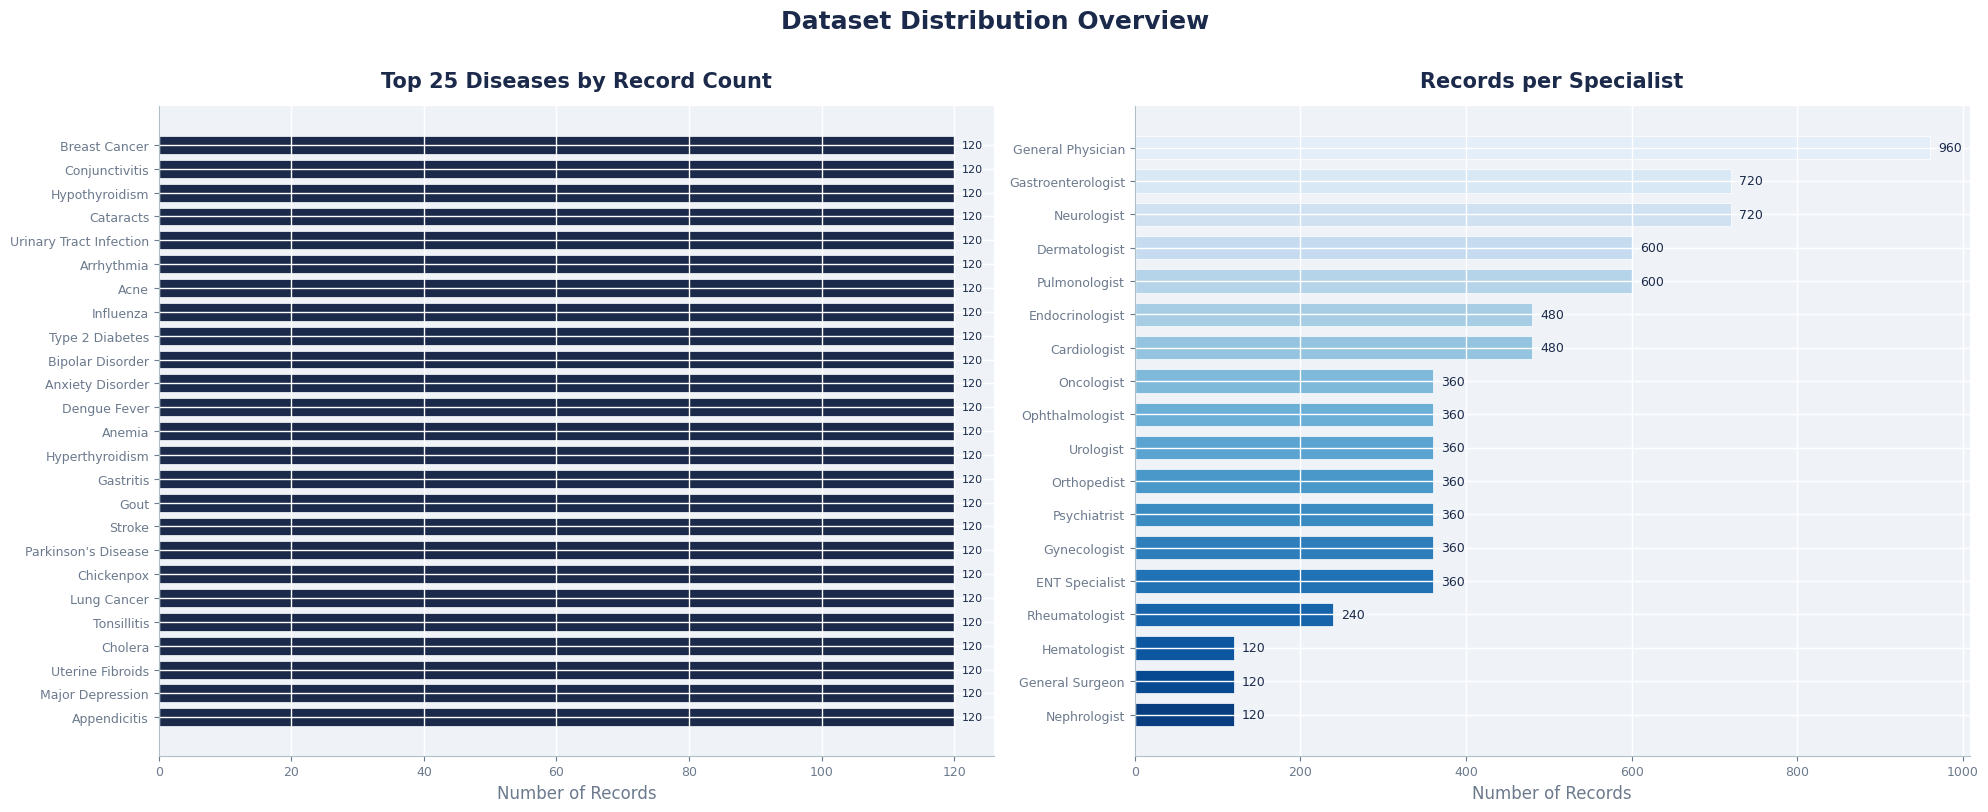

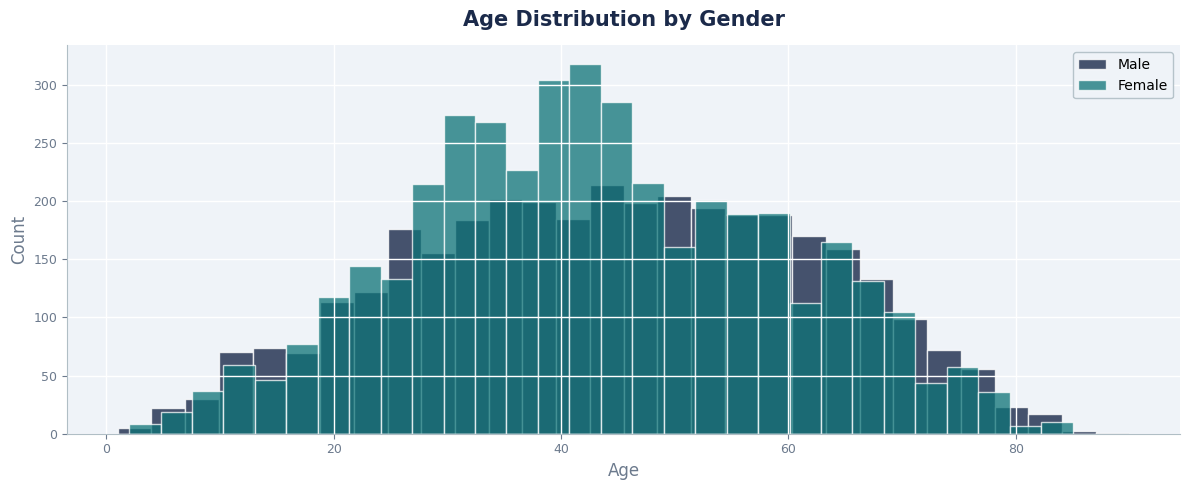

✅ Plots generated


In [ ]:
# ── Plot 1 : Disease & Specialist Distribution ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Dataset Distribution Overview',
             fontsize=18, fontweight='bold', color=NAVY, y=1.01)

disease_counts = df['disease'].value_counts()
bars0 = axes[0].barh(
    disease_counts.index[:25],
    disease_counts.values[:25],
    color=NAVY, edgecolor='white', linewidth=0.5, height=0.75
)
axes[0].set_title('Top 25 Diseases by Record Count', color=NAVY)
axes[0].set_xlabel('Number of Records', color=GRAY)
axes[0].invert_yaxis()
axes[0].set_facecolor(LIGHT)
style_spines(axes[0])
# value labels
for bar, val in zip(bars0, disease_counts.values[:25]):
    axes[0].text(val + max(disease_counts.values[:25]) * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8, color=NAVY)

sp_counts = df['specialist'].value_counts()
cmap_sp   = plt.cm.get_cmap('Blues', len(sp_counts) + 3)
sp_colors = [cmap_sp(i + 2) for i in range(len(sp_counts))]
bars1 = axes[1].barh(
    sp_counts.index, sp_counts.values,
    color=sp_colors, edgecolor='white', linewidth=0.5, height=0.7
)
axes[1].set_title('Records per Specialist', color=NAVY)
axes[1].set_xlabel('Number of Records', color=GRAY)
axes[1].invert_yaxis()
axes[1].set_facecolor(LIGHT)
style_spines(axes[1])
for bar, val in zip(bars1, sp_counts.values):
    axes[1].text(val + max(sp_counts.values) * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9, color=NAVY)

plt.tight_layout()
plt.savefig('distribution_plot.png')
plt.show()

# ── Plot 2 : Age Distribution by Gender ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[df['gender'] == 'Male']['age'],
        bins=30, alpha=0.80, color=NAVY,   label='Male',   edgecolor='white')
ax.hist(df[df['gender'] == 'Female']['age'],
        bins=30, alpha=0.75, color=TEAL,  label='Female', edgecolor='white')
ax.set_xlabel('Age', color=GRAY)
ax.set_ylabel('Count', color=GRAY)
ax.set_title('Age Distribution by Gender', color=NAVY)
ax.legend(framealpha=0.9)
style_spines(ax)
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()
print("✅ Plots generated")


##


## 🔧 Step 5 — Preprocessing & Feature Engineering


  Symptom feature columns : 85
  First 10 symptoms       : ['fever', 'cough', 'shortness_of_breath', 'wheezing', 'sore_throat', 'runny_nose', 'sneezing', 'chest_pain', 'rapid_breathing', 'phlegm']

  Gender encoding:
    Female → 0
    Male → 1

  Feature matrix X : (7680, 89)
  Disease classes  : 64
  Specialist cls   : 18

✅ Preprocessing complete


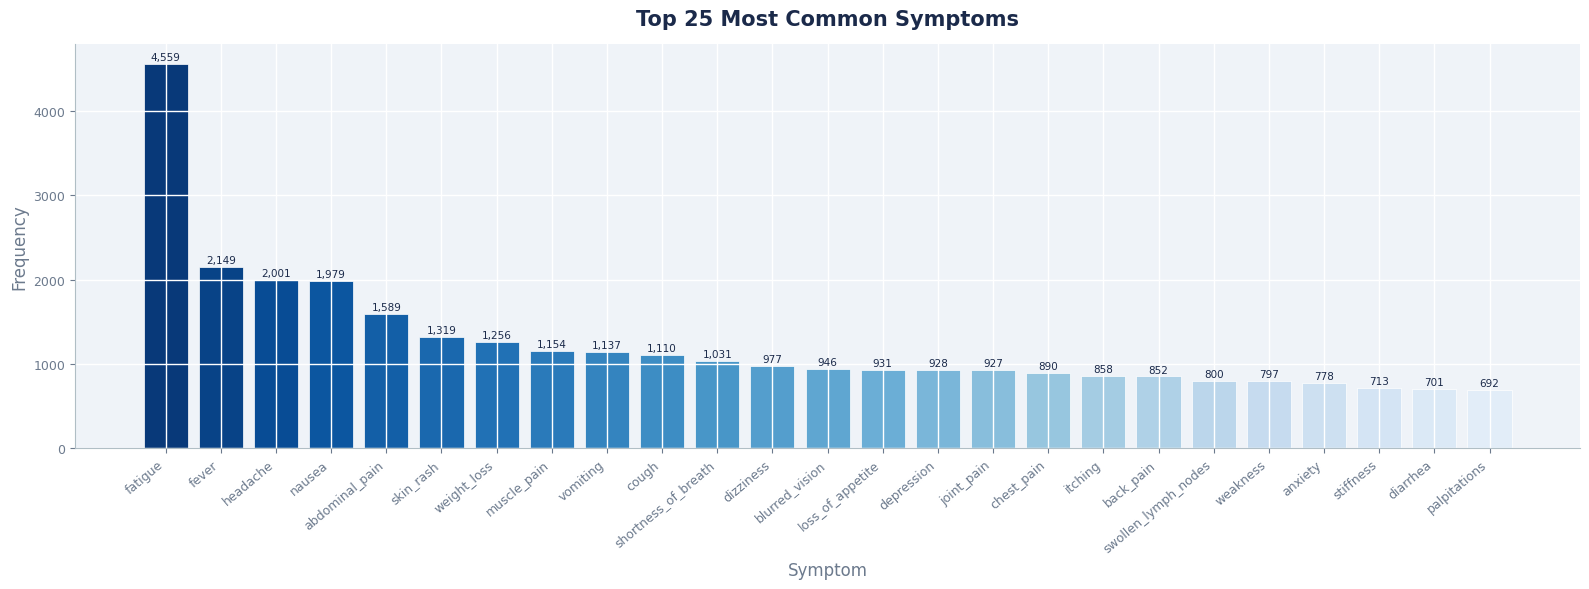

In [ ]:
META_COLS    = ['patient_id', 'disease', 'specialist', 'severity']
SYMPTOM_COLS = [c for c in df.columns
                if c not in META_COLS + ['age', 'gender', 'blood_group', 'division']]

print(f"  Symptom feature columns : {len(SYMPTOM_COLS)}")
print(f"  First 10 symptoms       : {SYMPTOM_COLS[:10]}")

le_gender     = LabelEncoder()
le_blood      = LabelEncoder()
le_division   = LabelEncoder()
le_disease    = LabelEncoder()
le_specialist = LabelEncoder()

df_enc = df.copy()
df_enc['gender_enc']   = le_gender.fit_transform(df['gender'])
df_enc['blood_enc']    = le_blood.fit_transform(df['blood_group'])
df_enc['division_enc'] = le_division.fit_transform(df['division'])

print("\n  Gender encoding:")
for i, cls in enumerate(le_gender.classes_):
    print(f"    {cls} → {i}")

FEATURE_COLS = SYMPTOM_COLS + ['age', 'gender_enc', 'blood_enc', 'division_enc']

X            = df_enc[FEATURE_COLS].values.astype(float)
y_disease    = le_disease.fit_transform(df['disease'])
y_specialist = le_specialist.fit_transform(df['specialist'])

print(f"\n  Feature matrix X : {X.shape}")
print(f"  Disease classes  : {len(le_disease.classes_)}")
print(f"  Specialist cls   : {len(le_specialist.classes_)}")
print("\n✅ Preprocessing complete")

# ── Symptom Frequency ─────────────────────────────────────────
symptom_freq = df[SYMPTOM_COLS].sum().sort_values(ascending=False)
top_symp     = symptom_freq.head(25)

fig, ax = plt.subplots(figsize=(16, 6))
cmap_s  = plt.cm.get_cmap('Blues', len(top_symp) + 4)
s_colors = [cmap_s(i + 3) for i in range(len(top_symp))][::-1]
bars = ax.bar(top_symp.index, top_symp.values,
              color=s_colors, edgecolor='white', linewidth=0.5)
ax.set_title('Top 25 Most Common Symptoms', color=NAVY)
ax.set_xlabel('Symptom', color=GRAY)
ax.set_ylabel('Frequency', color=GRAY)
ax.set_xticks(range(len(top_symp)))
ax.set_xticklabels(top_symp.index, rotation=40, ha='right', fontsize=9)
style_spines(ax)
# value labels on bars
for bar, val in zip(bars, top_symp.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(top_symp.values) * 0.005,
            f'{int(val):,}', ha='center', va='bottom', fontsize=7.5, color=NAVY)
plt.tight_layout()
plt.savefig('symptom_frequency.png')
plt.show()


##


## ✂️ Step 6 — Stratified Train / Test Split


In [ ]:
X_train, X_test, yd_train, yd_test, ys_train, ys_test = train_test_split(
    X, y_disease, y_specialist,
    test_size=0.2,
    random_state=42,
    stratify=y_disease
)

print(f"  Training set : {len(X_train):,} records (80%)")
print(f"  Test set     : {len(X_test):,} records (20%)")
print(f"\n  Class balance check (first 5 diseases):")
for i in range(min(5, len(le_disease.classes_))):
    tr = (yd_train == i).sum()
    te = (yd_test  == i).sum()
    print(f"    {le_disease.classes_[i]:<35} train={tr}  test={te}")

print("\n✅ Split complete")


  Training set : 6,144 records (80%)
  Test set     : 1,536 records (20%)

  Class balance check (first 5 diseases):
    Acne                                train=96  test=24
    Allergic Reaction                   train=96  test=24
    Alzheimer's Disease                 train=96  test=24
    Anemia                              train=96  test=24
    Anxiety Disorder                    train=96  test=24

✅ Split complete


##


## 🤖 Step 7 — Train & Compare All Models
This may take 2–5 minutes depending on dataset size.


In [ ]:
MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        min_samples_leaf=3, max_features='sqrt',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=3, random_state=42
    ),
    'KNN':         KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    # 'SVM':         SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    # 'Naive Bayes': MultinomialNB(),
}

results        = {}
trained_models = {}
scaler         = None
best_model_name = None
best_test_acc   = 0
best_model_obj  = None

print("=" * 80)
print(f"  {'Model':<22} {'Train Acc':>10} {'Test Acc':>10} "
      f"{'F1':>8} {'Precision':>10} {'Recall':>8} {'Gap':>8}")
print("=" * 80)

for name, model in MODELS.items():
    try:
        X_tr = np.nan_to_num(X_train)
        X_te = np.nan_to_num(X_test)

        if name=='KNN':
            if scaler is None:
                scaler = StandardScaler()
                scaler.fit(X_tr)
            X_tr = scaler.transform(X_tr)
            X_te = scaler.transform(X_te)

        model.fit(X_tr, yd_train)
        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)

        train_acc = accuracy_score(yd_train, y_pred_tr)
        test_acc  = accuracy_score(yd_test,  y_pred_te)
        f1        = f1_score(yd_test, y_pred_te, average='weighted', zero_division=0)
        prec      = precision_score(yd_test, y_pred_te, average='weighted', zero_division=0)
        rec       = recall_score(yd_test, y_pred_te, average='weighted', zero_division=0)
        gap       = train_acc - test_acc

        results[name] = {
            'train': train_acc, 'test': test_acc,
            'f1': f1, 'precision': prec, 'recall': rec,
            'overfit_gap': gap
        }
        trained_models[name] = model

        flag = '  ⭐ BEST' if test_acc > best_test_acc else ''
        print(f"  {name:<22} {train_acc:>10.4f} {test_acc:>10.4f} "
              f"{f1:>8.4f} {prec:>10.4f} {rec:>8.4f} "
              f"{gap*100:>7.1f}%{flag}")

        if test_acc > best_test_acc:
            best_test_acc   = test_acc
            best_model_name = name
            best_model_obj  = model

    except Exception as e:
        print(f"  {name:<22} FAILED → {e}")
        results[name] = {
            'train': 0, 'test': 0, 'f1': 0,
            'precision': 0, 'recall': 0, 'overfit_gap': 0
        }

print("=" * 80)
print(f"\n✅ Best Model  : {best_model_name}")
print(f"   Test Acc   : {best_test_acc*100:.2f}%")
print(f"   Overfit Gap: {results[best_model_name]['overfit_gap']*100:.2f}%  (< 5% is good)")


  Model                   Train Acc   Test Acc       F1  Precision   Recall      Gap
  Random Forest              0.9709     0.9440   0.9439     0.9455   0.9440     2.7%  ⭐ BEST
  XGBoost                    1.0000     0.9382   0.9383     0.9409   0.9382     6.2%
  Gradient Boosting          1.0000     0.9108   0.9111     0.9137   0.9108     8.9%
  Decision Tree              0.5470     0.5202   0.5316     0.6209   0.5202     2.7%
  KNN                        0.9406     0.9258   0.9254     0.9313   0.9258     1.5%

✅ Best Model  : Random Forest
   Test Acc   : 94.40%
   Overfit Gap: 2.69%  (< 5% is good)


##


## 📐 Step 8 — ROC-AUC Score


In [ ]:
print("Computing ROC-AUC (weighted OvR)...")
try:
    n_classes  = len(le_disease.classes_)
    X_te_clean = np.nan_to_num(X_test)
    y_bin      = label_binarize(yd_test, classes=range(n_classes))
    probs      = best_model_obj.predict_proba(X_te_clean)
    auc        = roc_auc_score(y_bin, probs, multi_class='ovr', average='weighted')
    print(f"  ROC-AUC : {auc:.4f}")
    results[best_model_name]['roc_auc'] = round(auc, 4)
except Exception as e:
    print(f"  ROC-AUC skipped: {e}")
    results[best_model_name]['roc_auc'] = None


Computing ROC-AUC (weighted OvR)...
  ROC-AUC : 0.9986


##


## 🔁 Step 9 — 10-Fold Cross Validation


Running 10-fold CV on: Random Forest ...

  Fold scores : [np.float64(0.9518), np.float64(0.9622), np.float64(0.9518), np.float64(0.9596), np.float64(0.9557), np.float64(0.9492), np.float64(0.9492), np.float64(0.9622), np.float64(0.9453), np.float64(0.9596)]
  Mean        : 0.9547
  Std Dev     : 0.0057  ← lower = more stable
  Min / Max   : 0.9453 / 0.9622


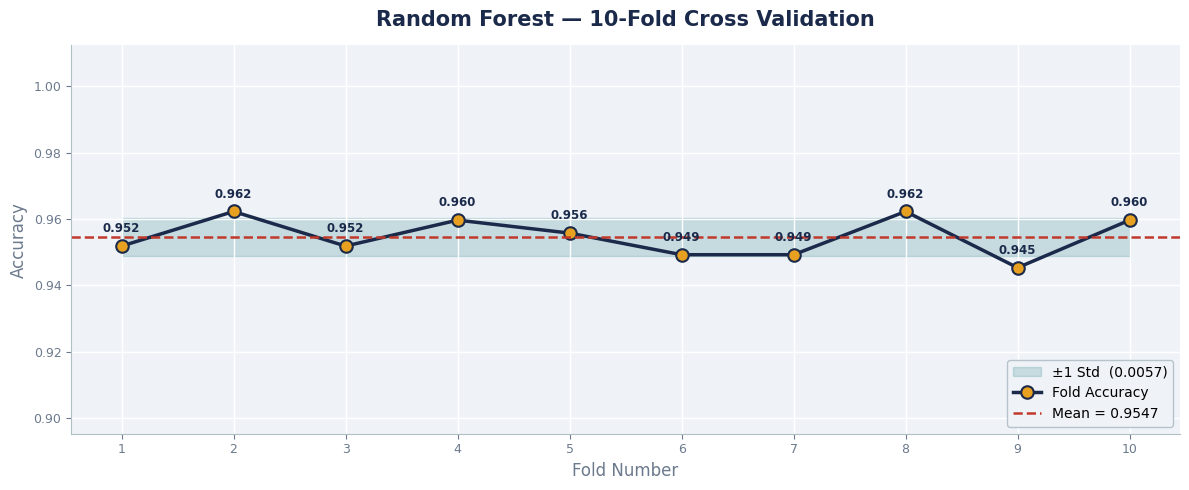

✅ Cross validation complete


In [ ]:
print(f"Running 10-fold CV on: {best_model_name} ...")
skf       = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_clean   = np.nan_to_num(X)
cv_scores = cross_val_score(
    best_model_obj, X_clean, y_disease,
    cv=skf, scoring='accuracy', n_jobs=-1
)

print(f"\n  Fold scores : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean        : {cv_scores.mean():.4f}")
print(f"  Std Dev     : {cv_scores.std():.4f}  ← lower = more stable")
print(f"  Min / Max   : {cv_scores.min():.4f} / {cv_scores.max():.4f}")

# ── CV Plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
folds   = range(1, 11)

ax.fill_between(folds,
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.18, color=TEAL, label=f'±1 Std  ({cv_scores.std():.4f})')
ax.plot(folds, cv_scores, 'o-',
        color=NAVY, linewidth=2.5, markersize=9,
        markerfacecolor=GOLD, markeredgecolor=NAVY, markeredgewidth=1.5,
        label='Fold Accuracy')
ax.axhline(cv_scores.mean(), color=CORAL, linestyle='--', linewidth=1.8,
           label=f'Mean = {cv_scores.mean():.4f}')

for fold, score in zip(folds, cv_scores):
    ax.annotate(f'{score:.3f}',
                xy=(fold, score),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color=NAVY, fontweight='bold')

ax.set_xlabel('Fold Number', color=GRAY)
ax.set_ylabel('Accuracy', color=GRAY)
ax.set_title(f'{best_model_name} — 10-Fold Cross Validation', color=NAVY)
ax.set_xticks(list(folds))
ax.set_ylim(max(0, cv_scores.min() - 0.05), min(1.02, cv_scores.max() + 0.05))
ax.legend(loc='lower right')
style_spines(ax)
plt.tight_layout()
plt.savefig('cross_validation.png')
plt.show()
print("✅ Cross validation complete")


##


## 📋 Step 10 — Detailed Evaluation (Best Model)


Classification Report — Random Forest
                          precision    recall  f1-score   support

                    Acne       0.91      0.88      0.89        24
       Allergic Reaction       0.96      0.96      0.96        24
     Alzheimer's Disease       1.00      1.00      1.00        24
                  Anemia       0.96      0.92      0.94        24
        Anxiety Disorder       0.96      0.96      0.96        24
            Appendicitis       1.00      0.92      0.96        24
              Arrhythmia       0.91      0.88      0.89        24
                  Asthma       1.00      1.00      1.00        24
        Bipolar Disorder       1.00      0.96      0.98        24
           Breast Cancer       0.96      1.00      0.98        24
              Bronchitis       0.91      0.88      0.89        24
                COVID-19       1.00      0.96      0.98        24
               Cataracts       0.88      0.92      0.90        24
              Chickenpox       0.92  

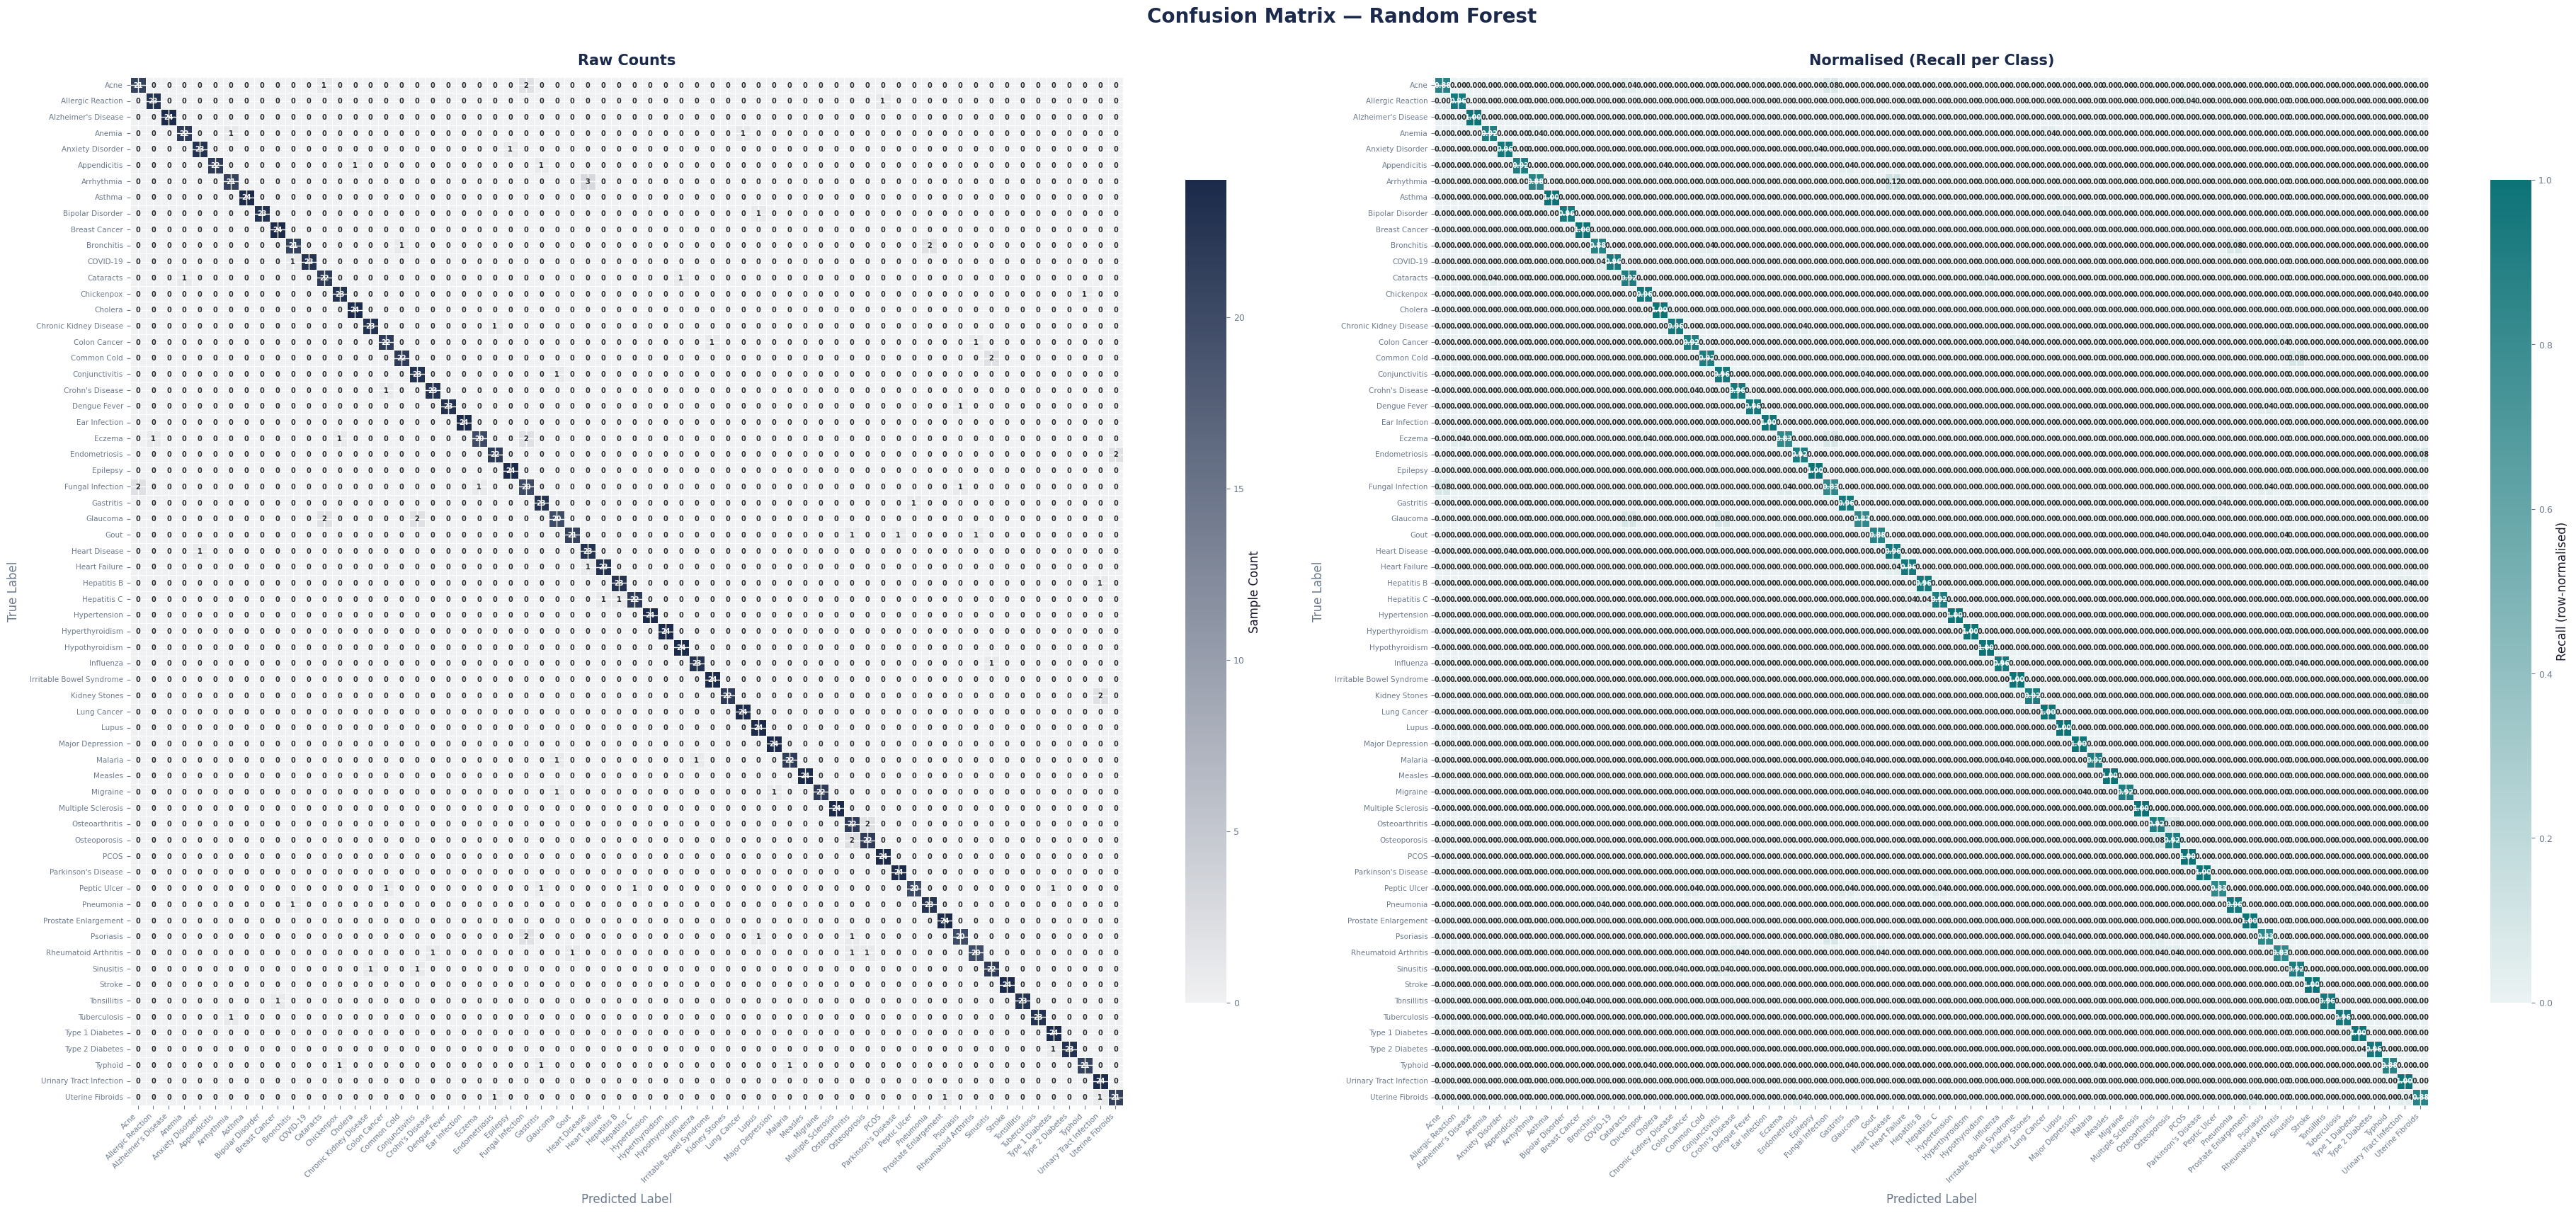

✅ Confusion matrix saved (counts + normalised)

Top 20 Most Important Features:
           feature  importance
               age    0.046492
       weight_loss    0.032259
             fever    0.031298
        joint_pain    0.026625
           itching    0.025062
         skin_rash    0.023351
             cough    0.022944
          headache    0.021689
       muscle_pain    0.019208
          dry_skin    0.018711
    abdominal_pain    0.018442
    blurred_vision    0.018341
    swollen_joints    0.018314
            nausea    0.018178
 painful_urination    0.017264
      palpitations    0.016726
frequent_urination    0.016328
         stiffness    0.016040
          eye_pain    0.015236
        chest_pain    0.015103


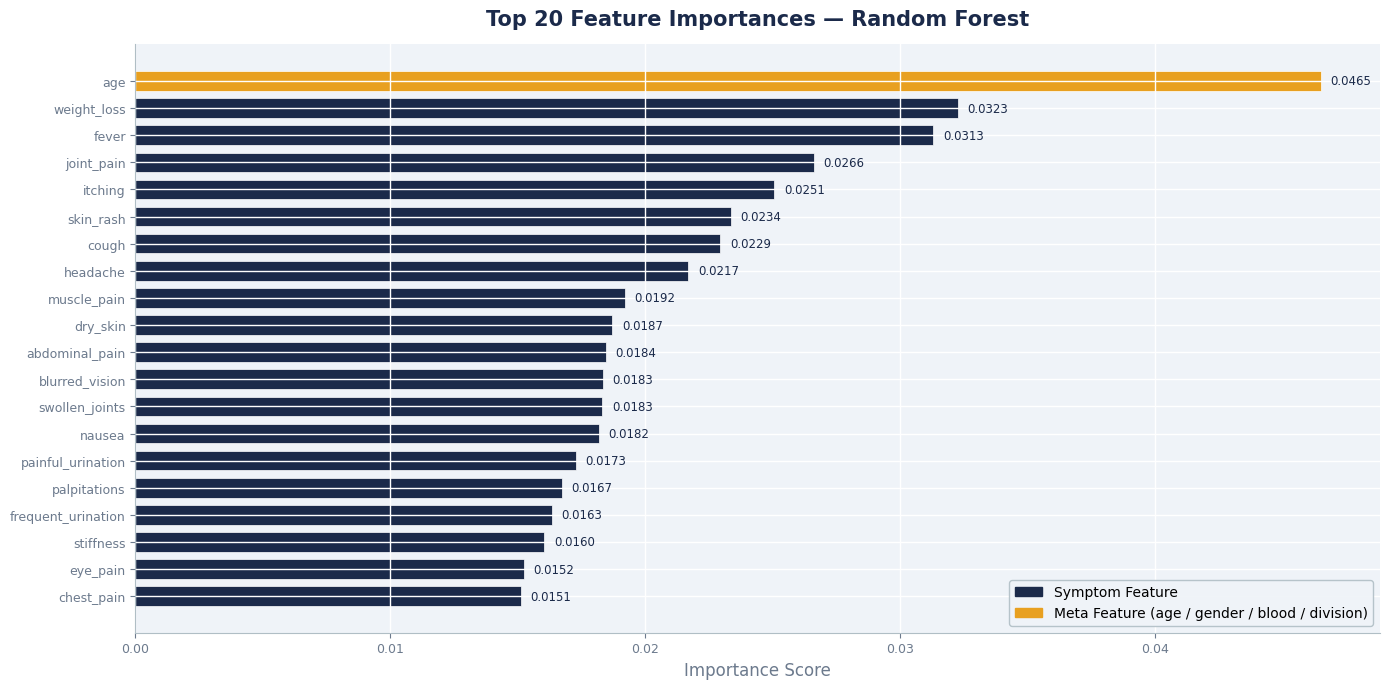

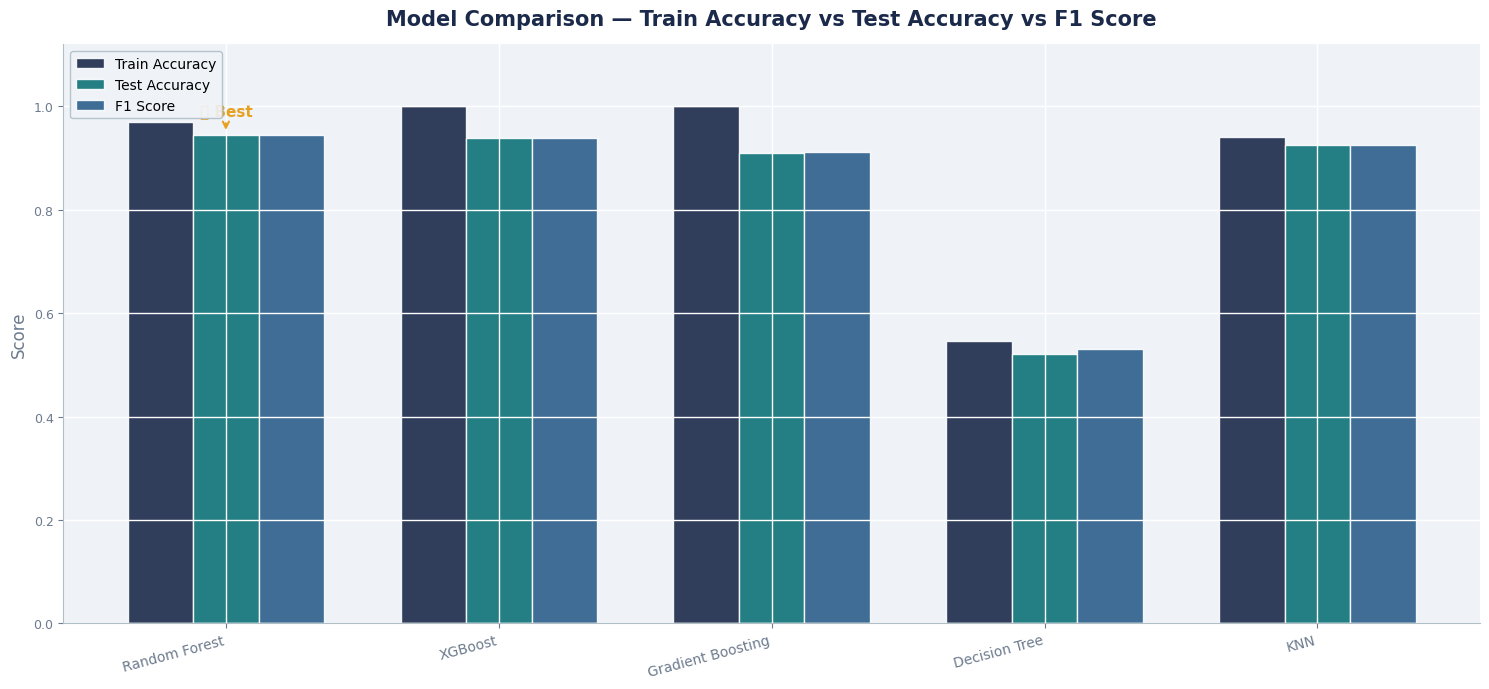

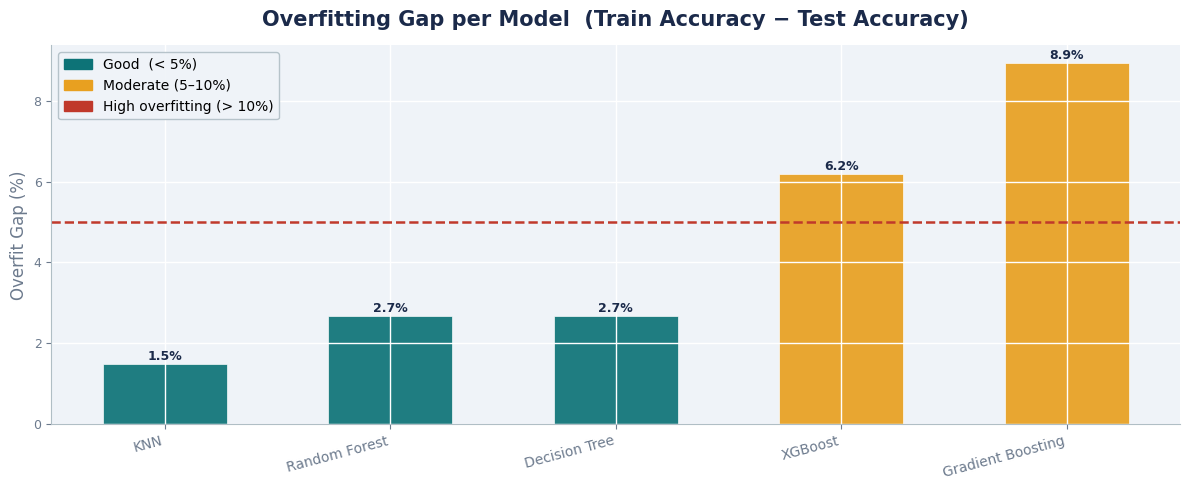

✅ All evaluation plots saved


In [ ]:
X_te_clean = np.nan_to_num(X_test)
y_pred     = best_model_obj.predict(X_te_clean)

print(f"Classification Report — {best_model_name}")
print("=" * 60)
report = classification_report(
    yd_test, y_pred,
    target_names=le_disease.classes_,
    zero_division=0
)
print(report)

# ── Confusion Matrix — FIXED & PROFESSIONAL ──────────────────
cm      = confusion_matrix(yd_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(38, 17))
fig.suptitle(f'Confusion Matrix — {best_model_name}',
             fontsize=20, fontweight='bold', color=NAVY, y=1.005)

# Left panel — Raw counts
sns.heatmap(
    cm, ax=axes[0],
    annot=True, fmt='d',
    cmap=sns.light_palette(NAVY, as_cmap=True),
    xticklabels=le_disease.classes_,
    yticklabels=le_disease.classes_,
    annot_kws={"size": 7, "weight": "bold"},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Sample Count', 'shrink': 0.8}
)
axes[0].set_title('Raw Counts', fontsize=15, fontweight='bold',
                  color=NAVY, pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=12, color=GRAY, labelpad=10)
axes[0].set_ylabel('True Label',      fontsize=12, color=GRAY, labelpad=10)
axes[0].tick_params(axis='x', labelsize=7.5, rotation=45)
axes[0].tick_params(axis='y', labelsize=7.5, rotation=0)
plt.setp(axes[0].get_xticklabels(), ha='right')

# Right panel — Row-normalised (recall per class)
sns.heatmap(
    cm_norm, ax=axes[1],
    annot=True, fmt='.2f',
    cmap=sns.light_palette(TEAL, as_cmap=True),
    xticklabels=le_disease.classes_,
    yticklabels=le_disease.classes_,
    annot_kws={"size": 7, "weight": "bold"},
    vmin=0, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Recall (row-normalised)', 'shrink': 0.8}
)
axes[1].set_title('Normalised (Recall per Class)',
                  fontsize=15, fontweight='bold', color=NAVY, pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=12, color=GRAY, labelpad=10)
axes[1].set_ylabel('True Label',      fontsize=12, color=GRAY, labelpad=10)
axes[1].tick_params(axis='x', labelsize=7.5, rotation=45)
axes[1].tick_params(axis='y', labelsize=7.5, rotation=0)
plt.setp(axes[1].get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved (counts + normalised)")

# ── Feature Importance ────────────────────────────────────────
if hasattr(best_model_obj, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 20 Most Important Features:")
    print(imp_df.head(20).to_string(index=False))

    top20  = imp_df.head(20)
    META   = {'age', 'gender_enc', 'blood_enc', 'division_enc'}
    colors = [GOLD if f in META else NAVY for f in top20['feature']]

    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(top20['feature'], top20['importance'],
                   color=colors, edgecolor='white', linewidth=0.5, height=0.72)
    ax.invert_yaxis()
    ax.set_xlabel('Importance Score', color=GRAY)
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}', color=NAVY)
    style_spines(ax)

    for bar, val in zip(bars, top20['importance']):
        ax.text(val + max(top20['importance']) * 0.008,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5, color=NAVY)

    legend_handles = [
        mpatches.Patch(color=NAVY, label='Symptom Feature'),
        mpatches.Patch(color=GOLD, label='Meta Feature (age / gender / blood / division)'),
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    imp_df.to_csv('feature_importance.csv', index=False)

# ── Model Comparison Chart ────────────────────────────────────
valid = {k: v for k, v in results.items() if v['test'] > 0}
names = list(valid.keys())
x     = np.arange(len(names))
w     = 0.24

fig, ax = plt.subplots(figsize=(15, 7))
b1 = ax.bar(x - w,     [valid[n]['train'] for n in names], w,
            label='Train Accuracy', color=NAVY,     alpha=0.90, edgecolor='white')
b2 = ax.bar(x,         [valid[n]['test']  for n in names], w,
            label='Test Accuracy',  color=TEAL,     alpha=0.90, edgecolor='white')
b3 = ax.bar(x + w,     [valid[n]['f1']    for n in names], w,
            label='F1 Score',       color=MID_BLUE, alpha=0.90, edgecolor='white')

# Star on best model
best_idx = names.index(best_model_name)
ax.annotate('⭐ Best',
            xy=(best_idx, valid[best_model_name]['test'] + 0.005),
            xytext=(best_idx, valid[best_model_name]['test'] + 0.04),
            ha='center', fontsize=11, color=GOLD, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', color=GRAY)
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison — Train Accuracy vs Test Accuracy vs F1 Score',
             color=NAVY)
ax.legend(loc='upper left')
style_spines(ax)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# ── Overfitting Gap Chart ─────────────────────────────────────
gaps   = [(n, v['overfit_gap'] * 100) for n, v in valid.items()]
gaps.sort(key=lambda x: x[1])
gnames = [g[0] for g in gaps]
gvals  = [g[1] for g in gaps]
gcolors = [TEAL if v < 5 else GOLD if v < 10 else CORAL for v in gvals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(gnames, gvals, color=gcolors,
              edgecolor='white', linewidth=0.5, alpha=0.92, width=0.55)
ax.axhline(5, color=CORAL, linestyle='--', linewidth=1.8,
           label='5 % threshold (acceptable)')
ax.set_ylabel('Overfit Gap (%)', color=GRAY)
ax.set_title('Overfitting Gap per Model  (Train Accuracy − Test Accuracy)',
             color=NAVY)
ax.set_xticks(range(len(gnames)))
ax.set_xticklabels(gnames, rotation=15, ha='right', fontsize=10)
style_spines(ax)

for bar, val in zip(bars, gvals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.1, f'{val:.1f}%',
            ha='center', fontsize=9, color=NAVY, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=TEAL,  label='Good  (< 5%)'),
    mpatches.Patch(color=GOLD,  label='Moderate (5–10%)'),
    mpatches.Patch(color=CORAL, label='High overfitting (> 10%)'),
]
ax.legend(handles=legend_handles, loc='upper left')
plt.tight_layout()
plt.savefig('overfitting_gap.png')
plt.show()

print("✅ All evaluation plots saved")


##


##


## 🔬 Step 10b — SHAP Analysis: Symptom → Disease & Specialist Importance
SHAP (SHapley Additive exPlanations) shows **which symptom contributes how much** to each prediction.
Used in Top-N doctor tier selection based on symptom impact + model confidence.

## 🩺 Step 11 — Train Specialist Recommendation Model (ML)
This is a SEPARATE ML model — not a dictionary lookup.


In [ ]:
print("Training specialist ML model...")

specialist_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
specialist_model.fit(np.nan_to_num(X_train), ys_train)

sp_pred_tr   = specialist_model.predict(np.nan_to_num(X_train))
sp_pred_te   = specialist_model.predict(np.nan_to_num(X_test))
sp_train_acc = accuracy_score(ys_train, sp_pred_tr)
sp_test_acc  = accuracy_score(ys_test,  sp_pred_te)
sp_f1        = f1_score(ys_test, sp_pred_te, average='weighted', zero_division=0)

print(f"\n  Train Accuracy  : {sp_train_acc:.4f}")
print(f"  Test Accuracy   : {sp_test_acc:.4f}")
print(f"  F1 Score        : {sp_f1:.4f}")
print(f"  Overfit Gap     : {(sp_train_acc - sp_test_acc)*100:.2f}%")

print(f"\n  Specialist classes ({len(le_specialist.classes_)}):")
for i, sp in enumerate(le_specialist.classes_):
    print(f"    {i:2}. {sp}")

print("\n✅ Specialist ML model trained")


Training specialist ML model...

  Train Accuracy  : 0.9494
  Test Accuracy   : 0.9421
  F1 Score        : 0.9414
  Overfit Gap     : 0.73%

  Specialist classes (18):
     0. Cardiologist
     1. Dermatologist
     2. ENT Specialist
     3. Endocrinologist
     4. Gastroenterologist
     5. General Physician
     6. General Surgeon
     7. Gynecologist
     8. Hematologist
     9. Nephrologist
    10. Neurologist
    11. Oncologist
    12. Ophthalmologist
    13. Orthopedist
    14. Psychiatrist
    15. Pulmonologist
    16. Rheumatologist
    17. Urologist

✅ Specialist ML model trained


Building SHAP explainer for disease model (TreeExplainer)...

  Top 10 Symptoms by SHAP Importance:
    fever                                SHAP = 0.00343
    cough                                SHAP = 0.00262
    abdominal_pain                       SHAP = 0.00250
    skin_rash                            SHAP = 0.00233
    weight_loss                          SHAP = 0.00202
    blurred_vision                       SHAP = 0.00200
    joint_pain                           SHAP = 0.00199
    itching                              SHAP = 0.00186
    palpitations                         SHAP = 0.00154
    shortness_of_breath                  SHAP = 0.00148


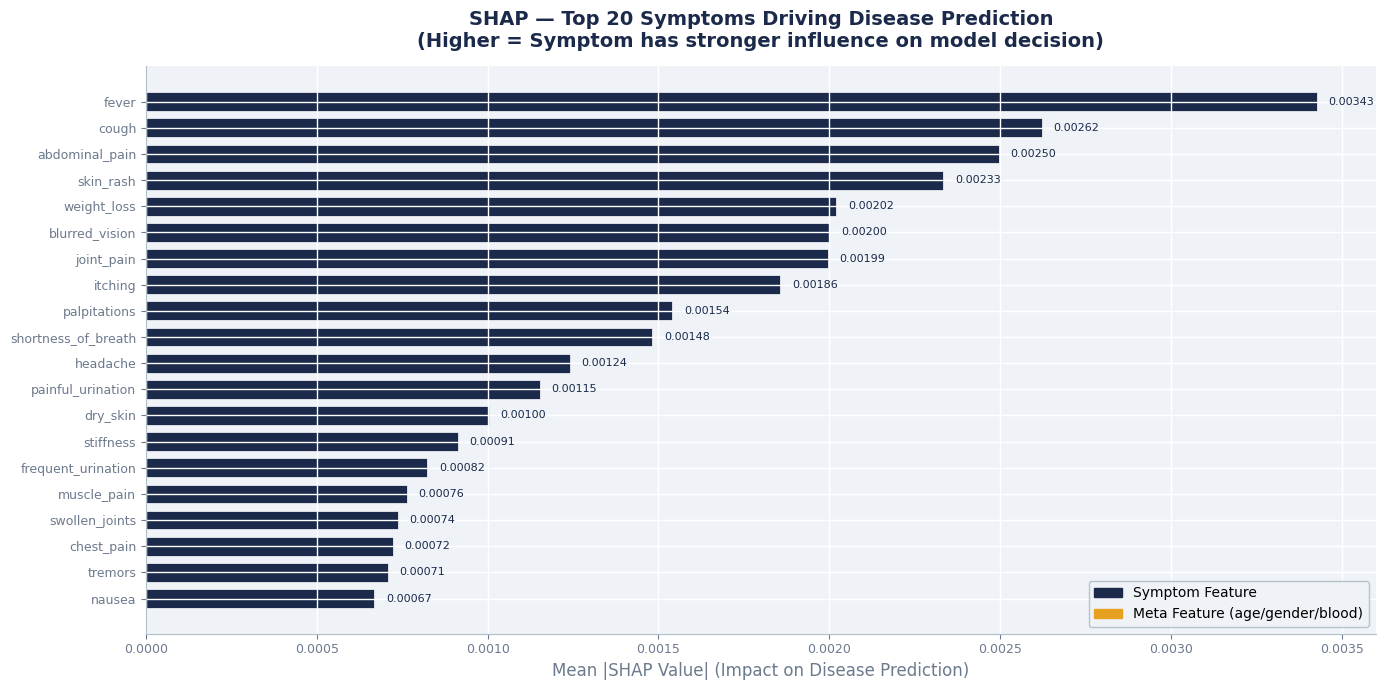

✅ SHAP global importance chart saved


In [ ]:
import shap

# ── SHAP Explainer for Best Disease Model ─────────────────────
print("Building SHAP explainer for disease model (TreeExplainer)...")
shap_explainer = shap.TreeExplainer(best_model_obj)

# Use a background sample (max 200 rows for speed)
X_bg = np.nan_to_num(X_test[:200])
shap_values = shap_explainer.shap_values(X_bg)  # shape: [n_classes, n_samples, n_features]

# shap_values is a list of arrays (one per class) for RF/tree multi-class
# Stack to (n_classes, n_samples, n_features)
# ── Normalise shap_values → always produce global_shap of shape (n_features,) ──
# SHAP returns different shapes depending on version and model type:
#   list of arrays : each element (n_samples, n_features)  [old API]
#   ndarray 3-D    : (n_samples, n_features, n_classes)    [new SHAP >= 0.40 RF]
#   ndarray 2-D    : (n_samples, n_features)               [binary/single output]
n_features = len(FEATURE_COLS)

if isinstance(shap_values, list):
    # Old list API — stack to (n_classes, n_samples, n_features) then mean over both axes
    shap_arr   = np.array(shap_values)              # (n_classes, n_samples, n_features)
    global_shap = np.abs(shap_arr).mean(axis=(0, 1))
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # New ndarray API: shape is (n_samples, n_features, n_classes)
    # axis=1 is features, axis=2 is classes — mean over samples and classes
    assert shap_values.shape[1] == n_features, (
        f"Expected axis-1 = n_features ({n_features}), got shape {shap_values.shape}"
    )
    global_shap = np.abs(shap_values).mean(axis=(0, 2))  # mean over samples & classes → (n_features,)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    # Binary / single-output: (n_samples, n_features)
    global_shap = np.abs(shap_values).mean(axis=0)       # → (n_features,)
else:
    raise ValueError(f"Unexpected shap_values type/shape: {type(shap_values)}, "
                     f"shape={getattr(shap_values, 'shape', 'N/A')}")

assert len(global_shap) == n_features, (
    f"global_shap has {len(global_shap)} entries but FEATURE_COLS has {n_features}"
)
global_shap_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'mean_shap':  global_shap
}).sort_values('mean_shap', ascending=False)

# Separate symptom vs meta features
META_SET = {'age', 'gender_enc', 'blood_enc', 'division_enc'}
sym_shap = global_shap_df[~global_shap_df['feature'].isin(META_SET)].head(20)
meta_shap = global_shap_df[global_shap_df['feature'].isin(META_SET)]

print(f"\n  Top 10 Symptoms by SHAP Importance:")
for _, row in sym_shap.head(10).iterrows():
    print(f"    {row['feature']:<35}  SHAP = {row['mean_shap']:.5f}")

# ══════════════════════════════════════════════════════════════
# CHART 1 — Global Symptom SHAP Bar Chart (Defense-ready)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 7))
colors_shap = [GOLD if f in META_SET else NAVY for f in sym_shap['feature']]

bars = ax.barh(
    sym_shap['feature'],
    sym_shap['mean_shap'],
    color=colors_shap, edgecolor='white', linewidth=0.5, height=0.72
)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value| (Impact on Disease Prediction)', color=GRAY)
ax.set_title('SHAP — Top 20 Symptoms Driving Disease Prediction\n'
             '(Higher = Symptom has stronger influence on model decision)',
             color=NAVY, fontsize=14)
style_spines(ax)

for bar, val in zip(bars, sym_shap['mean_shap']):
    ax.text(val + max(sym_shap['mean_shap']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.5f}', va='center', fontsize=8, color=NAVY)

legend_handles = [
    mpatches.Patch(color=NAVY, label='Symptom Feature'),
    mpatches.Patch(color=GOLD, label='Meta Feature (age/gender/blood)'),
]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('shap_global_symptom_importance.png')
plt.show()
print("✅ SHAP global importance chart saved")


Computing SHAP for Specialist model...


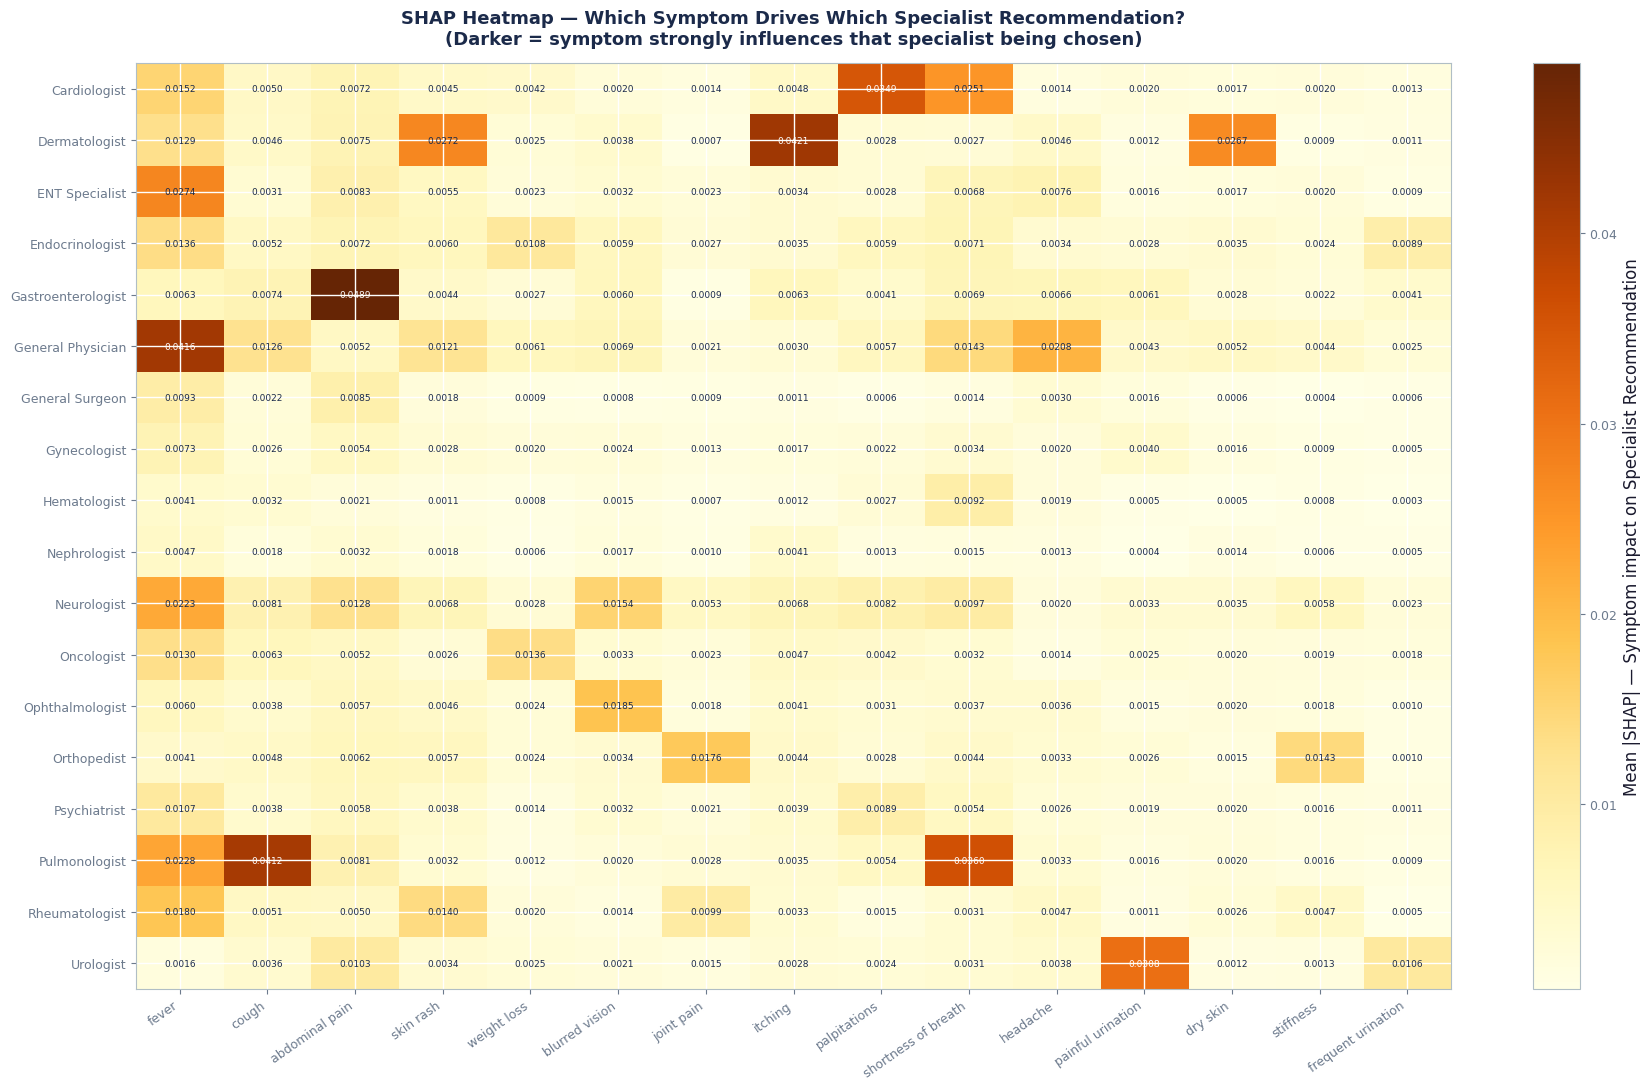

✅ SHAP specialist heatmap saved


In [ ]:
import shap
# ══════════════════════════════════════════════════════════════
# CHART 2 — Per-Specialist SHAP: Which symptoms matter most
#            for recommending each specialist?
# ══════════════════════════════════════════════════════════════
print("Computing SHAP for Specialist model...")
shap_sp_explainer = shap.TreeExplainer(specialist_model)
shap_sp_values    = shap_sp_explainer.shap_values(X_bg)

# ── Normalise specialist shap_values → per_sp_mean shape (n_specialists, n_features) ──
n_features = len(FEATURE_COLS)
n_specialists = len(le_specialist.classes_)

if isinstance(shap_sp_values, list):
    # Old list API: list of (n_samples, n_features), one per specialist class
    # stack → (n_specialists, n_samples, n_features), mean over samples → (n_specialists, n_features)
    shap_sp_arr = np.array(shap_sp_values)              # (n_specialists, n_samples, n_features)
    per_sp_mean = np.abs(shap_sp_arr).mean(axis=1)      # (n_specialists, n_features)
elif isinstance(shap_sp_values, np.ndarray) and shap_sp_values.ndim == 3:
    # New SHAP ndarray: (n_samples, n_features, n_specialists)
    # axis=1 = features, axis=2 = specialists
    assert shap_sp_values.shape[1] == n_features, (
        f"Expected axis-1 = n_features ({n_features}), got shape {shap_sp_values.shape}"
    )
    # mean over samples (axis=0) → (n_features, n_specialists), then transpose → (n_specialists, n_features)
    per_sp_mean = np.abs(shap_sp_values).mean(axis=0).T  # (n_specialists, n_features)
elif isinstance(shap_sp_values, np.ndarray) and shap_sp_values.ndim == 2:
    # Single-output fallback: broadcast same weights across all specialists
    row = np.abs(shap_sp_values).mean(axis=0)            # (n_features,)
    per_sp_mean = np.tile(row, (n_specialists, 1))        # (n_specialists, n_features)
else:
    raise ValueError(f"Unexpected shap_sp_values type/shape: {type(shap_sp_values)}, "
                     f"shape={getattr(shap_sp_values, 'shape', 'N/A')}")

# Pick top symptoms only (exclude meta)
symptom_idx = [i for i, f in enumerate(FEATURE_COLS) if f not in META_SET]
symptom_names = [FEATURE_COLS[i] for i in symptom_idx]

# Build a df: rows=specialist, cols=symptom; top 15 symptoms by global SHAP
top15_sym_names = sym_shap['feature'].values[:15].tolist()
top15_sym_idx   = [FEATURE_COLS.index(s) for s in top15_sym_names if s in FEATURE_COLS]
top15_sym_names = [FEATURE_COLS[i] for i in top15_sym_idx]

sp_shap_matrix = per_sp_mean[:, top15_sym_idx]  # (n_specialists, 15)

# Store for use in predict_disease
SP_SHAP_MATRIX    = sp_shap_matrix
SP_SHAP_SYMS      = top15_sym_names
SP_SHAP_EXPLAINER = shap_sp_explainer

# ── Heatmap: Specialist × Symptom SHAP ───────────────────────
fig, ax = plt.subplots(figsize=(18, max(6, len(le_specialist.classes_) * 0.5 + 2)))

im = ax.imshow(sp_shap_matrix, aspect='auto',
               cmap='YlOrBr', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Mean |SHAP| — Symptom impact on Specialist Recommendation')

ax.set_xticks(range(len(top15_sym_names)))
ax.set_xticklabels([s.replace('_', ' ') for s in top15_sym_names],
                   rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(le_specialist.classes_)))
ax.set_yticklabels(le_specialist.classes_, fontsize=9)
ax.set_title('SHAP Heatmap — Which Symptom Drives Which Specialist Recommendation?\n'
             '(Darker = symptom strongly influences that specialist being chosen)',
             color=NAVY, fontsize=13)

# Add value annotations
for i in range(sp_shap_matrix.shape[0]):
    for j in range(sp_shap_matrix.shape[1]):
        val = sp_shap_matrix[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=6.5,
                color='white' if val > sp_shap_matrix.max() * 0.6 else NAVY)

plt.tight_layout()
plt.savefig('shap_specialist_heatmap.png', dpi=180)
plt.show()
print("✅ SHAP specialist heatmap saved")



  🏥 SHAP-POWERED TOP-N SPECIALIST TIER SELECTION

──────────────────────────────────────────────────────────────────────
  Case 1 — Flu-like (Male)


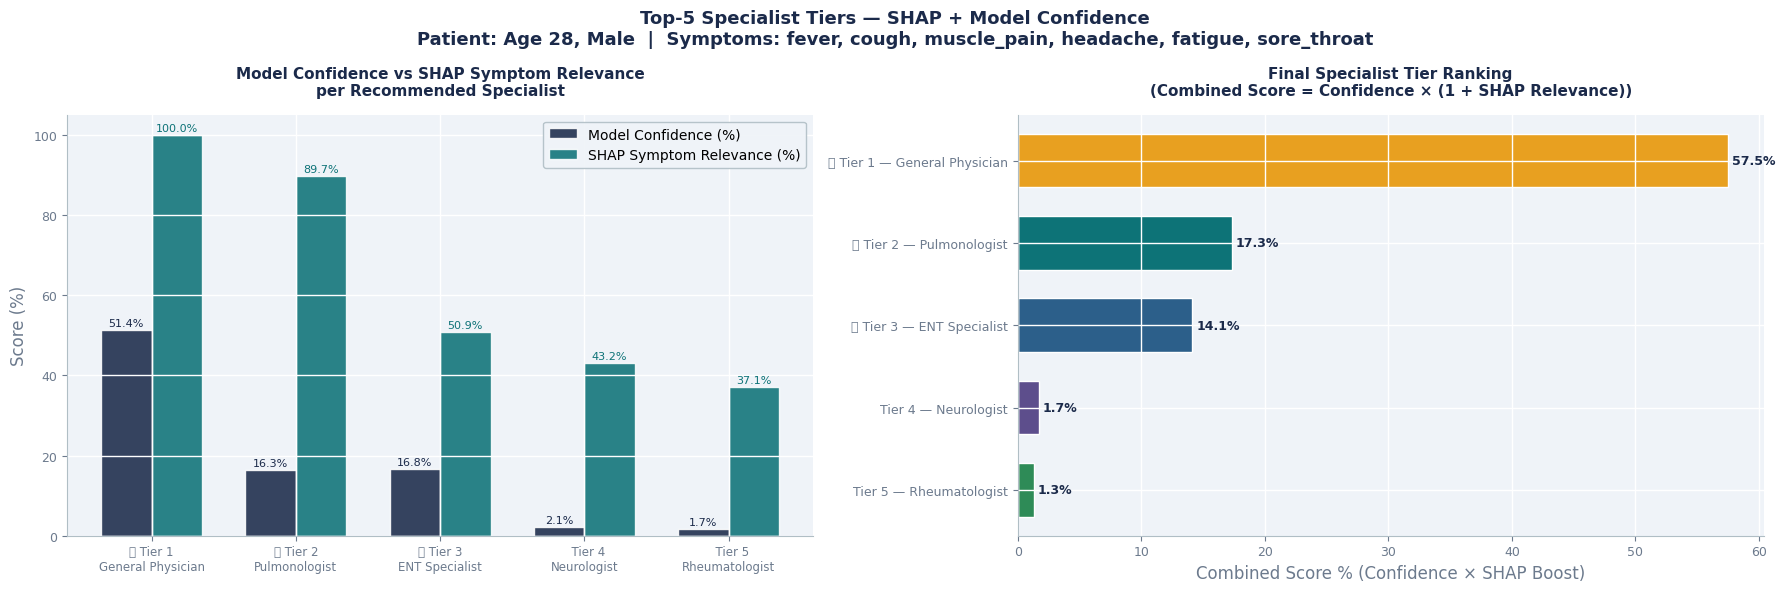

  Patient: Age 28, Male
  Symptoms: fever, cough, muscle_pain, headache, fatigue, sore_throat

  🥇 Tier 1     General Physician                   Conf= 51.4%  SHAP=100.0%  Score= 57.5%  ████████████████████████████
  🥈 Tier 2     Pulmonologist                       Conf= 16.3%  SHAP= 89.7%  Score= 17.3%  ████████
  🥉 Tier 3     ENT Specialist                      Conf= 16.8%  SHAP= 50.9%  Score= 14.1%  ███████
    Tier 4     Neurologist                         Conf=  2.1%  SHAP= 43.2%  Score=  1.7%  
    Tier 5     Rheumatologist                      Conf=  1.7%  SHAP= 37.1%  Score=  1.3%  

──────────────────────────────────────────────────────────────────────
  Case 2 — Diabetic symptoms (Female)


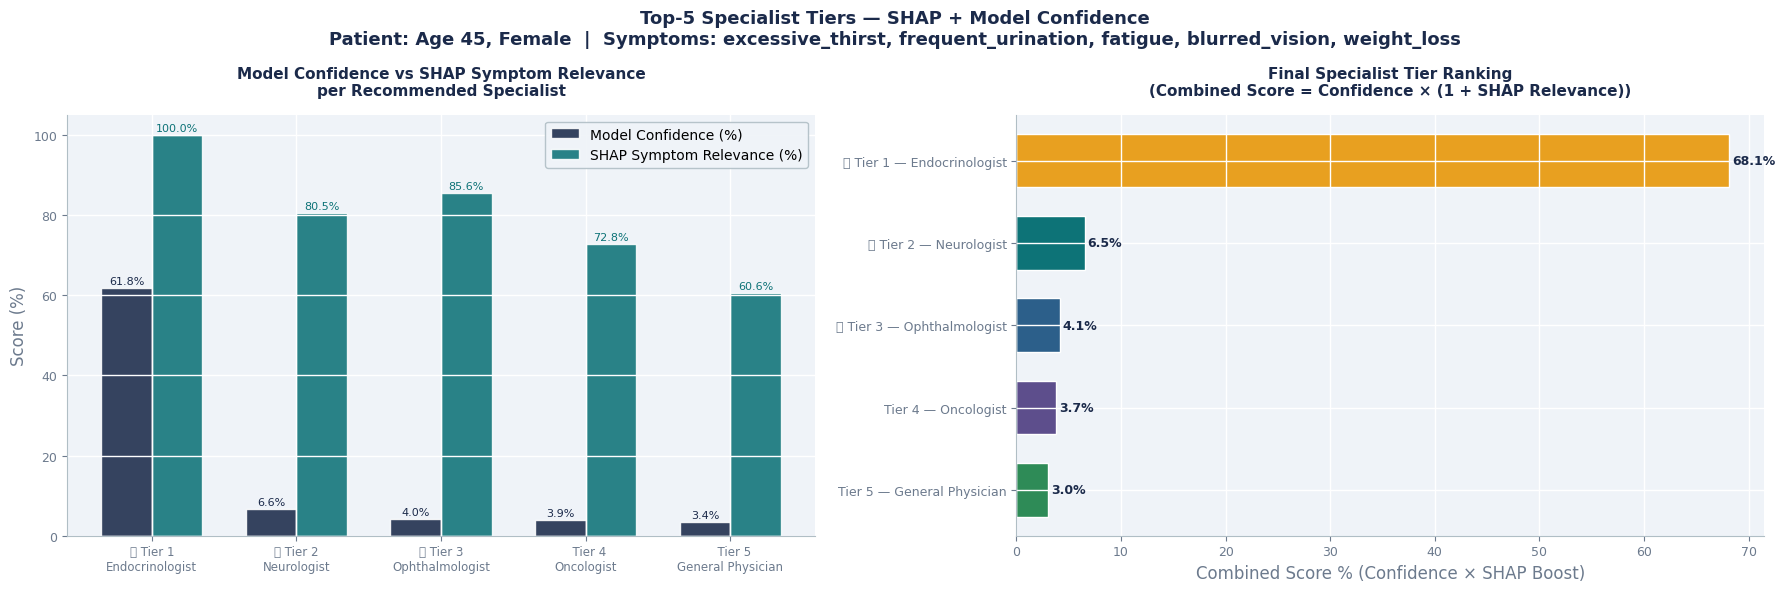

  Patient: Age 45, Female
  Symptoms: excessive_thirst, frequent_urination, fatigue, blurred_vision, weight_loss

  🥇 Tier 1     Endocrinologist                     Conf= 61.8%  SHAP=100.0%  Score= 68.1%  ██████████████████████████████████
  🥈 Tier 2     Neurologist                         Conf=  6.6%  SHAP= 80.5%  Score=  6.5%  ███
  🥉 Tier 3     Ophthalmologist                     Conf=  4.0%  SHAP= 85.6%  Score=  4.1%  ██
    Tier 4     Oncologist                          Conf=  3.9%  SHAP= 72.8%  Score=  3.7%  █
    Tier 5     General Physician                   Conf=  3.4%  SHAP= 60.6%  Score=  3.0%  █

──────────────────────────────────────────────────────────────────────
  Case 3 — Heart symptoms (Male)


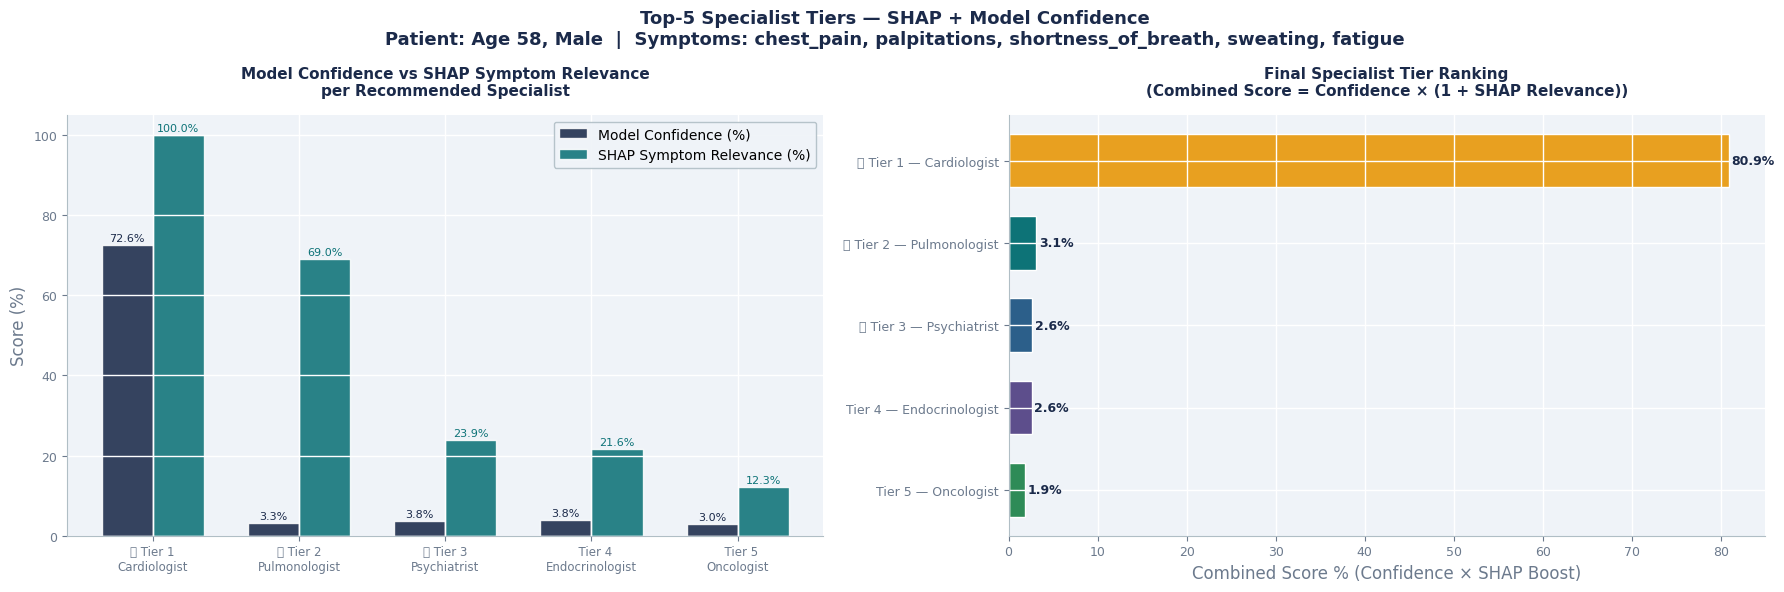

  Patient: Age 58, Male
  Symptoms: chest_pain, palpitations, shortness_of_breath, sweating, fatigue

  🥇 Tier 1     Cardiologist                        Conf= 72.6%  SHAP=100.0%  Score= 80.9%  ████████████████████████████████████████
  🥈 Tier 2     Pulmonologist                       Conf=  3.3%  SHAP= 69.0%  Score=  3.1%  █
  🥉 Tier 3     Psychiatrist                        Conf=  3.8%  SHAP= 23.9%  Score=  2.6%  █
    Tier 4     Endocrinologist                     Conf=  3.8%  SHAP= 21.6%  Score=  2.6%  █
    Tier 5     Oncologist                          Conf=  3.0%  SHAP= 12.3%  Score=  1.9%  

──────────────────────────────────────────────────────────────────────
  Case 4 — PCOS (Female)


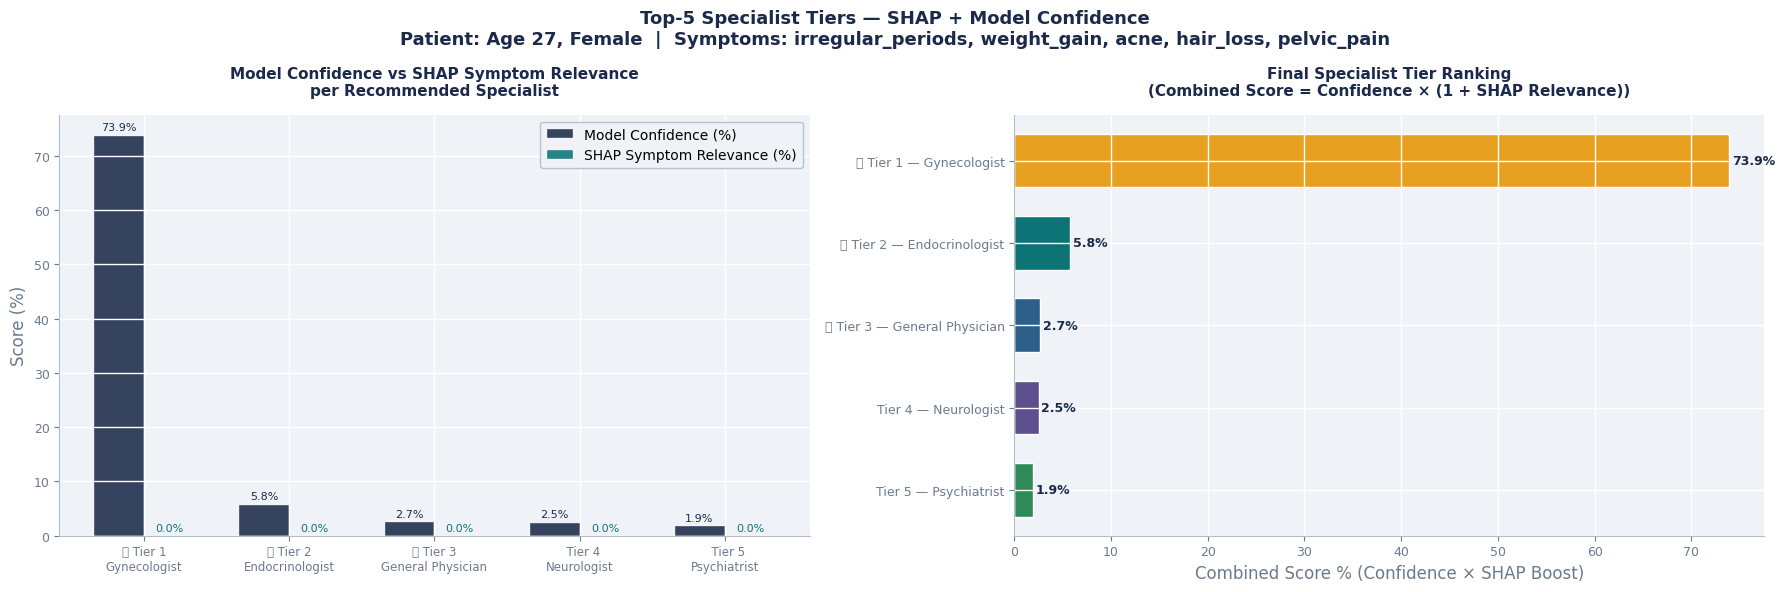

  Patient: Age 27, Female
  Symptoms: irregular_periods, weight_gain, acne, hair_loss, pelvic_pain

  🥇 Tier 1     Gynecologist                        Conf= 73.9%  SHAP=  0.0%  Score= 73.9%  ████████████████████████████████████
  🥈 Tier 2     Endocrinologist                     Conf=  5.8%  SHAP=  0.0%  Score=  5.8%  ██
  🥉 Tier 3     General Physician                   Conf=  2.7%  SHAP=  0.0%  Score=  2.7%  █
    Tier 4     Neurologist                         Conf=  2.5%  SHAP=  0.0%  Score=  2.5%  █
    Tier 5     Psychiatrist                        Conf=  1.9%  SHAP=  0.0%  Score=  1.9%  

──────────────────────────────────────────────────────────────────────
  Case 5 — Dengue (Male)


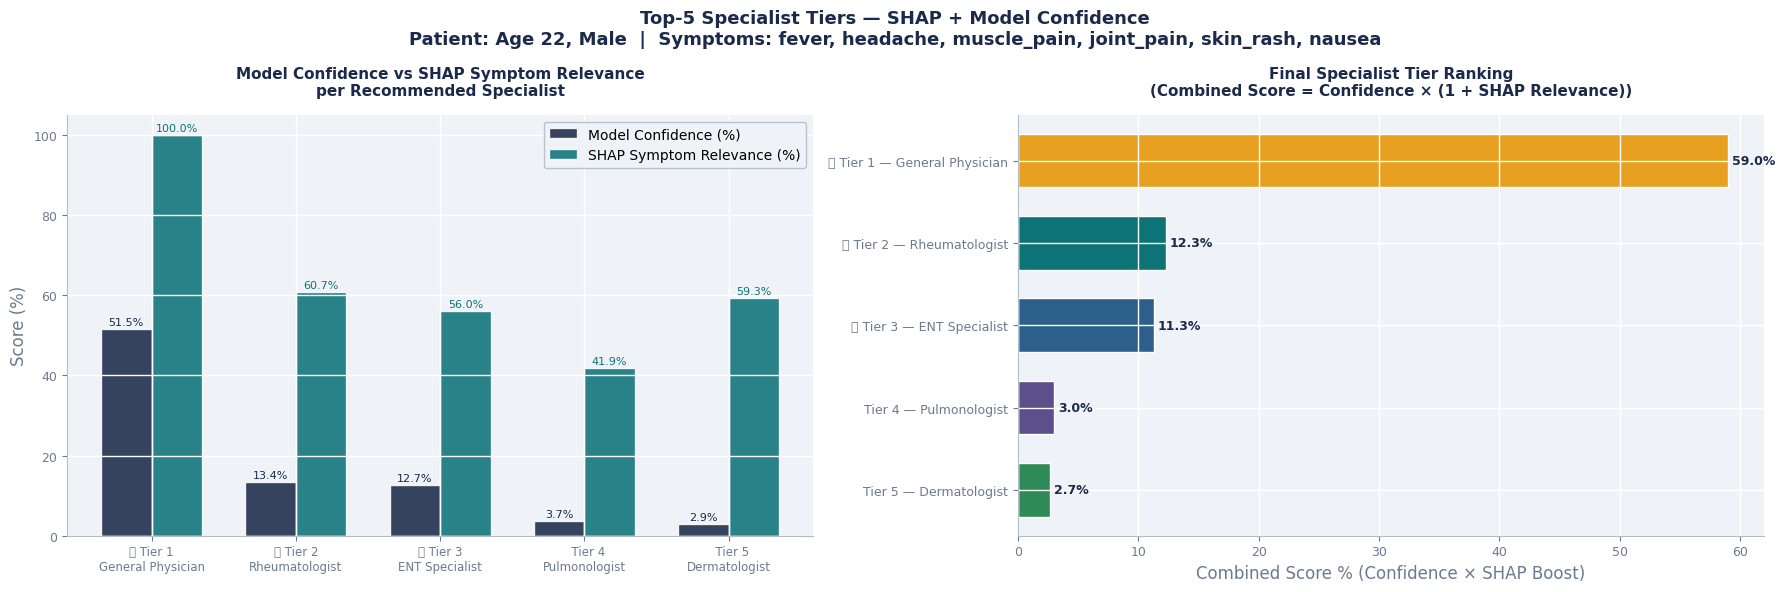

  Patient: Age 22, Male
  Symptoms: fever, headache, muscle_pain, joint_pain, skin_rash, nausea

  🥇 Tier 1     General Physician                   Conf= 51.5%  SHAP=100.0%  Score= 59.0%  █████████████████████████████
  🥈 Tier 2     Rheumatologist                      Conf= 13.4%  SHAP= 60.7%  Score= 12.3%  ██████
  🥉 Tier 3     ENT Specialist                      Conf= 12.7%  SHAP= 56.0%  Score= 11.3%  █████
    Tier 4     Pulmonologist                       Conf=  3.7%  SHAP= 41.9%  Score=  3.0%  █
    Tier 5     Dermatologist                       Conf=  2.9%  SHAP= 59.3%  Score=  2.7%  █

✅ SHAP Top-N Tier Doctor Selection complete!


In [ ]:
# ── Test cases (also used by SHAP charts below) ──────────────
test_cases = [
    {'name': 'Case 1 — Flu-like (Male)',
     'symptoms': ['fever', 'cough', 'muscle_pain', 'headache', 'fatigue', 'sore_throat'],
     'age': 28, 'gender': 'Male'},
    {'name': 'Case 2 — Diabetic symptoms (Female)',
     'symptoms': ['excessive_thirst', 'frequent_urination', 'fatigue', 'blurred_vision', 'weight_loss'],
     'age': 45, 'gender': 'Female'},
    {'name': 'Case 3 — Heart symptoms (Male)',
     'symptoms': ['chest_pain', 'palpitations', 'shortness_of_breath', 'sweating', 'fatigue'],
     'age': 58, 'gender': 'Male'},
    {'name': 'Case 4 — PCOS (Female)',
     'symptoms': ['irregular_periods', 'weight_gain', 'acne', 'hair_loss', 'pelvic_pain'],
     'age': 27, 'gender': 'Female'},
    {'name': 'Case 5 — Dengue (Male)',
     'symptoms': ['fever', 'headache', 'muscle_pain', 'joint_pain', 'skin_rash', 'nausea'],
     'age': 22, 'gender': 'Male'},
]

# ══════════════════════════════════════════════════════════════
# CHART 3 — SHAP × Confidence: Top-N Tier Doctor Selection
# Combines model confidence (predict_proba) + SHAP relevance
# to rank and tier specialists for a patient's active symptoms
# ══════════════════════════════════════════════════════════════

def shap_topn_doctors(symptoms_list, age, gender,
                      blood_group='O+', division='Dhaka',
                      top_n=5, plot=True):
    """
    Returns top-N specialist tiers ranked by:
      Score = model_confidence * (1 + symptom_shap_relevance)

    SHAP relevance = average SHAP weight of the patient's active symptoms
    for each specialist class.
    """
    # ── Build feature vector ──────────────────────────────────
    vec     = {s: 0 for s in SYMPTOM_COLS}
    matched = []
    for s in symptoms_list:
        s_clean = s.lower().strip().replace(' ', '_')
        if s_clean in vec:
            vec[s_clean] = 1
            matched.append(s_clean)

    try:    g_enc = int(le_gender.transform([gender])[0])
    except: g_enc = 0
    try:    b_enc = int(le_blood.transform([blood_group])[0])
    except: b_enc = 0
    try:    d_enc = int(le_division.transform([division])[0])
    except: d_enc = 0

    feature_vec = [vec[s] for s in SYMPTOM_COLS] + [age, g_enc, b_enc, d_enc]
    X_input     = np.array(feature_vec, dtype=float).reshape(1, -1)
    X_input_clean = np.nan_to_num(X_input)

    # ── Model confidence (specialist) ─────────────────────────
    sp_probs = specialist_model.predict_proba(X_input_clean)[0]  # (n_specialists,)

    # ── SHAP relevance per specialist for patient's symptoms ──
    active_sym_idx = [
        FEATURE_COLS.index(s)
        for s in matched
        if s in FEATURE_COLS and s in top15_sym_names
    ]

    if len(active_sym_idx) > 0:
        # SP_SHAP_MATRIX shape: (n_specialists, 15)
        # For each specialist: average SHAP for the patient's active symptoms
        active_col_idx = [
            top15_sym_names.index(FEATURE_COLS[fi])
            for fi in active_sym_idx
            if FEATURE_COLS[fi] in top15_sym_names
        ]
        if active_col_idx:
            shap_relevance = SP_SHAP_MATRIX[:, active_col_idx].mean(axis=1)  # (n_sp,)
        else:
            shap_relevance = np.zeros(len(le_specialist.classes_))
    else:
        shap_relevance = np.zeros(len(le_specialist.classes_))

    # Normalise SHAP relevance to [0,1]
    sr_max = shap_relevance.max()
    if sr_max > 0:
        shap_rel_norm = shap_relevance / sr_max
    else:
        shap_rel_norm = shap_relevance

    # ── Combined Score ────────────────────────────────────────
    # Score = confidence * (1 + shap_relevance_norm)
    # This boosts specialists whose key symptoms match the patient
    combined_score = sp_probs * (1 + shap_rel_norm)

    # Normalise to % for display
    combined_pct = combined_score / combined_score.sum() * 100

    # ── Rank ──────────────────────────────────────────────────
    ranked_idx = np.argsort(combined_score)[::-1][:top_n]

    tiers = []
    for rank, idx in enumerate(ranked_idx, 1):
        tier_label = ('🥇 Tier 1' if rank == 1 else
                      '🥈 Tier 2' if rank == 2 else
                      '🥉 Tier 3' if rank == 3 else
                      f'  Tier {rank}')
        tiers.append({
            'rank':          rank,
            'tier':          tier_label,
            'specialist':    le_specialist.classes_[idx],
            'confidence':    float(sp_probs[idx]),
            'shap_rel':      float(shap_rel_norm[idx]),
            'combined_pct':  float(combined_pct[idx]),
        })

    # ── Plot ──────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(
            f'Top-{top_n} Specialist Tiers — SHAP + Model Confidence\n'
            f'Patient: Age {age}, {gender}  |  '
            f'Symptoms: {", ".join(matched[:6])}{" ..." if len(matched) > 6 else ""}',
            fontsize=13, fontweight='bold', color=NAVY
        )

        sp_names    = [t['specialist'] for t in tiers]
        conf_vals   = [t['confidence'] * 100 for t in tiers]
        shap_vals   = [t['shap_rel'] * 100    for t in tiers]
        combo_vals  = [t['combined_pct']       for t in tiers]

        tier_colors = [GOLD, TEAL, MID_BLUE, '#5D4E8C', '#2E8B57'][:top_n]

        # Left: Grouped bar — Confidence vs SHAP Relevance
        x  = np.arange(len(sp_names))
        bw = 0.35
        b1 = axes[0].bar(x - bw/2, conf_vals,  bw, label='Model Confidence (%)',
                         color=NAVY, alpha=0.88, edgecolor='white')
        b2 = axes[0].bar(x + bw/2, shap_vals, bw, label='SHAP Symptom Relevance (%)',
                         color=TEAL, alpha=0.88, edgecolor='white')
        for bar, v in zip(b1, conf_vals):
            axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                         f'{v:.1f}%', ha='center', va='bottom', fontsize=8, color=NAVY)
        for bar, v in zip(b2, shap_vals):
            axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                         f'{v:.1f}%', ha='center', va='bottom', fontsize=8, color=TEAL)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(
            [f'{t["tier"]}\n{s}' for t, s in zip(tiers, sp_names)],
            fontsize=8.5, ha='center'
        )
        axes[0].set_ylabel('Score (%)', color=GRAY)
        axes[0].set_title('Model Confidence vs SHAP Symptom Relevance\nper Recommended Specialist',
                          color=NAVY, fontsize=11)
        axes[0].legend()
        style_spines(axes[0])

        # Right: Combined Score horizontal bar (ranking)
        bars_r = axes[1].barh(
            [f'{t["tier"]} — {t["specialist"]}' for t in tiers[::-1]],
            combo_vals[::-1],
            color=tier_colors[::-1], edgecolor='white', height=0.65
        )
        for bar, val in zip(bars_r, combo_vals[::-1]):
            axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                         f'{val:.1f}%', va='center', fontsize=9, color=NAVY, fontweight='bold')
        axes[1].set_xlabel('Combined Score % (Confidence × SHAP Boost)', color=GRAY)
        axes[1].set_title('Final Specialist Tier Ranking\n(Combined Score = Confidence × (1 + SHAP Relevance))',
                          color=NAVY, fontsize=11)
        style_spines(axes[1])

        plt.tight_layout()
        plt.savefig('shap_topn_doctor_tier.png', dpi=180)
        plt.show()

    return tiers


# ── Run SHAP Top-N on all live test cases ─────────────────────
print("\n" + "=" * 70)
print("  🏥 SHAP-POWERED TOP-N SPECIALIST TIER SELECTION")
print("=" * 70)

for case in test_cases:
    print(f"\n{'─'*70}")
    print(f"  {case['name']}")
    tiers = shap_topn_doctors(
        case['symptoms'], case['age'], case['gender'], top_n=5, plot=True
    )
    print(f"  Patient: Age {case['age']}, {case['gender']}")
    print(f"  Symptoms: {', '.join([s.lower().replace(' ','_') for s in case['symptoms']])}")
    print()
    for t in tiers:
        bar = '█' * int(t['combined_pct'] / 2)
        print(f"  {t['tier']:<12} {t['specialist']:<35}"
              f" Conf={t['confidence']*100:5.1f}%  "
              f"SHAP={t['shap_rel']*100:5.1f}%  "
              f"Score={t['combined_pct']:5.1f}%  {bar}")

print("\n" + "=" * 70)
print("✅ SHAP Top-N Tier Doctor Selection complete!")


Showing SHAP symptom breakdown for: Case 1 — Flu-like (Male)


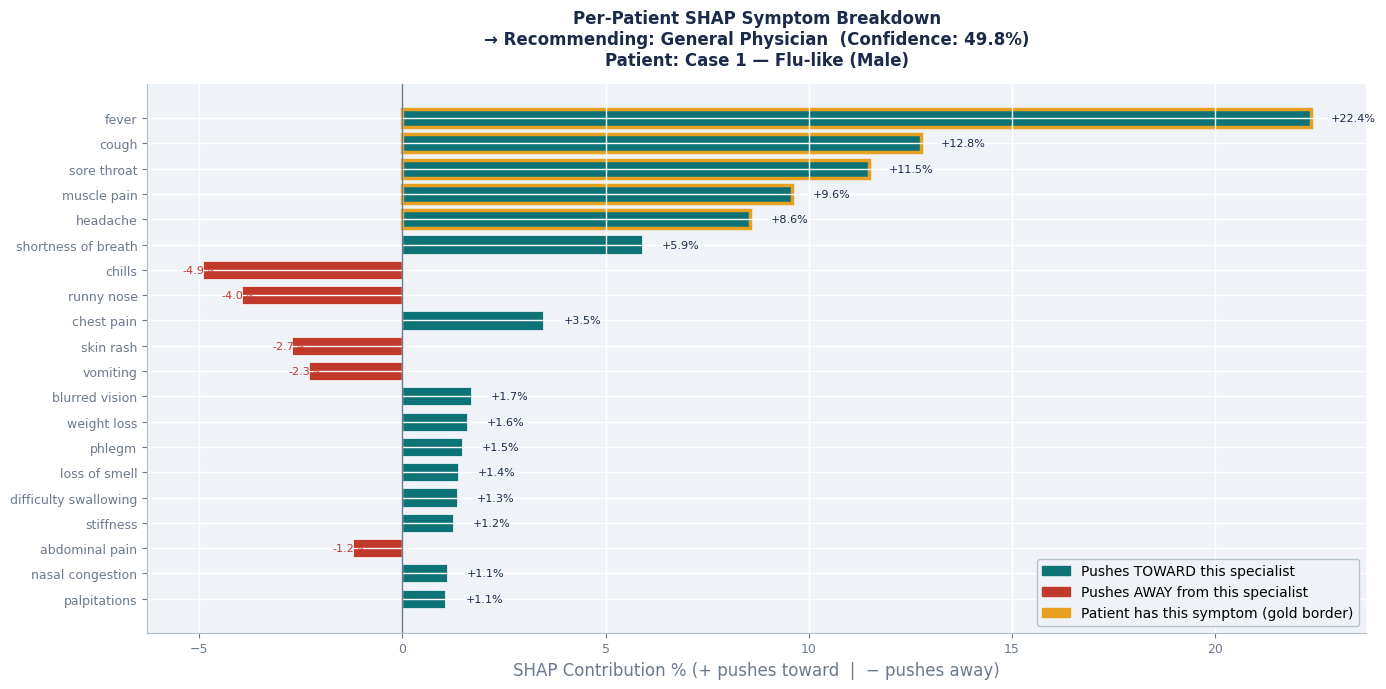

✅ Per-patient SHAP breakdown saved for: Case 1 — Flu-like (Male)


In [ ]:
# ── Test cases (also used by SHAP charts below) ──────────────
test_cases = [
    {'name': 'Case 1 — Flu-like (Male)',
     'symptoms': ['fever', 'cough', 'muscle_pain', 'headache', 'fatigue', 'sore_throat'],
     'age': 28, 'gender': 'Male'},
    {'name': 'Case 2 — Diabetic symptoms (Female)',
     'symptoms': ['excessive_thirst', 'frequent_urination', 'fatigue', 'blurred_vision', 'weight_loss'],
     'age': 45, 'gender': 'Female'},
    {'name': 'Case 3 — Heart symptoms (Male)',
     'symptoms': ['chest_pain', 'palpitations', 'shortness_of_breath', 'sweating', 'fatigue'],
     'age': 58, 'gender': 'Male'},
    {'name': 'Case 4 — PCOS (Female)',
     'symptoms': ['irregular_periods', 'weight_gain', 'acne', 'hair_loss', 'pelvic_pain'],
     'age': 27, 'gender': 'Female'},
    {'name': 'Case 5 — Dengue (Male)',
     'symptoms': ['fever', 'headache', 'muscle_pain', 'joint_pain', 'skin_rash', 'nausea'],
     'age': 22, 'gender': 'Male'},
]

# ══════════════════════════════════════════════════════════════
# CHART 4 — Per-Prediction Symptom SHAP Breakdown
# For one patient: show each symptom's % contribution to
# the top specialist recommendation (waterfall-style bar)
# ══════════════════════════════════════════════════════════════

demo = test_cases[0]   # Change index to show different case
print(f"Showing SHAP symptom breakdown for: {demo['name']}")

# Rebuild feature vector for demo case
vec_demo = {s: 0 for s in SYMPTOM_COLS}
matched_demo = []
for s in demo['symptoms']:
    sc = s.lower().strip().replace(' ', '_')
    if sc in vec_demo:
        vec_demo[sc] = 1
        matched_demo.append(sc)

try:    g_enc_d = int(le_gender.transform([demo['gender']])[0])
except: g_enc_d = 0

fvec_demo  = [vec_demo[s] for s in SYMPTOM_COLS] + [demo['age'], g_enc_d, 0, 0]
X_demo     = np.array(fvec_demo, dtype=float).reshape(1, -1)
X_demo_c   = np.nan_to_num(X_demo)

# SHAP values for this single patient (specialist model)
sv_demo = SP_SHAP_EXPLAINER.shap_values(X_demo_c)  # list of (1, n_features)

# Get top-1 specialist index
sp_probs_demo = specialist_model.predict_proba(X_demo_c)[0]
top_sp_idx    = int(np.argmax(sp_probs_demo))
top_sp_name   = le_specialist.classes_[top_sp_idx]

# ── Extract (n_features,) SHAP vector for the top specialist ──
# Handle all SHAP return shapes:
#   list  : sv_demo[top_sp_idx] is (1, n_features) → take [0]
#   3-D ndarray (new RF): sv_demo is (1, n_features, n_classes) → sv_demo[0, :, top_sp_idx]
#   2-D ndarray: sv_demo is (1, n_features) → sv_demo[0]
if isinstance(sv_demo, list):
    sv_for_top = np.array(sv_demo[top_sp_idx][0])       # (n_features,)
elif isinstance(sv_demo, np.ndarray) and sv_demo.ndim == 3:
    sv_for_top = sv_demo[0, :, top_sp_idx]               # (n_features,)
elif isinstance(sv_demo, np.ndarray) and sv_demo.ndim == 2:
    sv_for_top = sv_demo[0]                              # (n_features,)
else:
    sv_for_top = np.array(sv_demo).flatten()[:len(FEATURE_COLS)]

sv_for_top = np.array(sv_for_top).flatten()             # ensure 1-D

# Keep only symptom features that were active (value=1)
active_mask = np.array(fvec_demo[:len(SYMPTOM_COLS)]) == 1
sym_sv      = sv_for_top[:len(SYMPTOM_COLS)]

# All symptoms with non-zero SHAP
nonzero_mask = (np.abs(sym_sv) > 0)
plot_syms    = np.array(SYMPTOM_COLS)[nonzero_mask]
plot_vals    = sym_sv[nonzero_mask]
plot_active  = active_mask[nonzero_mask]

# Sort by absolute SHAP
sort_idx  = np.argsort(np.abs(plot_vals))[::-1][:20]
plot_syms = plot_syms[sort_idx]
plot_vals = plot_vals[sort_idx]
plot_active = plot_active[sort_idx]

# % contribution
total_abs = np.abs(plot_vals).sum()
plot_pct  = plot_vals / (total_abs + 1e-10) * 100

# Colors: positive=NAVY, negative=CORAL; active symptom get border
bar_colors = [TEAL if v >= 0 else CORAL for v in plot_pct]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    [s.replace('_', ' ') for s in plot_syms],
    plot_pct,
    color=bar_colors,
    edgecolor=[GOLD if a else 'white' for a in plot_active],
    linewidth=[2.5 if a else 0.5 for a in plot_active],
    height=0.72
)
ax.invert_yaxis()
ax.axvline(0, color=GRAY, linewidth=1.0)
ax.set_xlabel('SHAP Contribution % (+ pushes toward  |  − pushes away)', color=GRAY)
ax.set_title(
    f'Per-Patient SHAP Symptom Breakdown\n'
    f'→ Recommending: {top_sp_name}  '
    f'(Confidence: {sp_probs_demo[top_sp_idx]*100:.1f}%)\n'
    f'Patient: {demo["name"]}',
    color=NAVY, fontsize=12
)
style_spines(ax)

for bar, val in zip(bars, plot_pct):
    offset = 0.5 if val >= 0 else -0.5
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=8,
            color=NAVY if val >= 0 else CORAL)

legend_handles = [
    mpatches.Patch(color=TEAL,  label='Pushes TOWARD this specialist'),
    mpatches.Patch(color=CORAL, label='Pushes AWAY from this specialist'),
    mpatches.Patch(color=GOLD,  label='Patient has this symptom (gold border)'),
]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('shap_patient_symptom_breakdown.png', dpi=180)
plt.show()
print(f"✅ Per-patient SHAP breakdown saved for: {demo['name']}")


##


## 💾 Step 12 — Save All Models & Encoders


In [ ]:
os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_model_obj,     'saved_models/disease_model.pkl')
joblib.dump(best_model_name,    'saved_models/best_model_name.pkl')
joblib.dump(specialist_model,   'saved_models/specialist_model.pkl')

joblib.dump(le_disease,         'saved_models/le_disease.pkl')
joblib.dump(le_specialist,      'saved_models/le_specialist.pkl')
joblib.dump(le_gender,          'saved_models/le_gender.pkl')
joblib.dump(le_blood,           'saved_models/le_blood.pkl')
joblib.dump(le_division,        'saved_models/le_division.pkl')

joblib.dump(SYMPTOM_COLS,       'saved_models/symptom_columns.pkl')
joblib.dump(FEATURE_COLS,       'saved_models/feature_columns.pkl')

if scaler is not None:
    joblib.dump(scaler,         'saved_models/scaler.pkl')
    print("  ✅ scaler.pkl saved")

disease_specialist_map = (
    df[['disease', 'specialist']]
    .drop_duplicates()
    .set_index('disease')['specialist']
    .to_dict()
)
joblib.dump(disease_specialist_map, 'saved_models/disease_specialist_map.pkl')


# ── Save SHAP explainers ─────────────────────────────────────
joblib.dump(shap_explainer,     'saved_models/shap_disease_explainer.pkl')
joblib.dump(SP_SHAP_EXPLAINER,  'saved_models/shap_specialist_explainer.pkl')
joblib.dump(SP_SHAP_MATRIX,     'saved_models/shap_specialist_matrix.pkl')
joblib.dump(top15_sym_names,    'saved_models/shap_top15_symptom_names.pkl')
print("  ✅ SHAP explainers saved")
for name, m in trained_models.items():
    safe = name.lower().replace(' ', '_')
    joblib.dump(m, f'saved_models/{safe}_model.pkl')

with open('saved_models/classification_report.txt', 'w') as f:
    f.write(f"Best Model    : {best_model_name}\n")
    f.write(f"Test Accuracy : {best_test_acc:.4f}\n")
    f.write(f"CV Mean±Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n\n")
    f.write(report)

metrics_summary = {
    'best_model':          best_model_name,
    'test_accuracy':       round(best_test_acc, 4),
    'cv_mean':             round(float(cv_scores.mean()), 4),
    'cv_std':              round(float(cv_scores.std()), 4),
    'f1_weighted':         round(results[best_model_name]['f1'], 4),
    'precision':           round(results[best_model_name]['precision'], 4),
    'recall':              round(results[best_model_name]['recall'], 4),
    'roc_auc':             results[best_model_name].get('roc_auc', None),
    'specialist_test_acc': round(sp_test_acc, 4),
    'specialist_f1':       round(sp_f1, 4),
    'n_diseases':          int(len(le_disease.classes_)),
    'n_specialists':       int(len(le_specialist.classes_)),
    'n_symptoms':          int(len(SYMPTOM_COLS)),
    'n_features':          int(len(FEATURE_COLS)),
    'train_size':          int(len(X_train)),
    'test_size':           int(len(X_test)),
}
with open('saved_models/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("\n📁 All saved files:")
for fname in sorted(os.listdir('saved_models')):
    size = os.path.getsize(f'saved_models/{fname}')
    print(f"   {fname:<48} {size/1024:>8.1f} KB")

print("\n✅ All models saved successfully!")


  ✅ scaler.pkl saved
  ✅ SHAP explainers saved

📁 All saved files:
   best_model_name.pkl                                   0.0 KB
   classification_report.txt                             4.5 KB
   decision_tree_model.pkl                             200.3 KB
   disease_model.pkl                                 31877.1 KB
   disease_specialist_map.pkl                            1.3 KB
   feature_columns.pkl                                   1.2 KB
   gradient_boosting_model.pkl                       35864.3 KB
   knn_model.pkl                                      4321.3 KB
   le_blood.pkl                                          0.5 KB
   le_disease.pkl                                        1.4 KB
   le_division.pkl                                       0.5 KB
   le_gender.pkl                                         0.5 KB
   le_specialist.pkl                                     0.7 KB
   metrics_summary.json                                  0.4 KB
   random_forest_model.pkl           

##


## 🧪 Step 13 — Live Prediction Test


In [ ]:
def predict_disease(symptoms_list, age, gender,
                    blood_group='O+', division='Dhaka', top_n=3):
    """
    Predict disease + specialist from symptoms.
    Uses TWO independent ML models (not a dictionary lookup).
    """
    vec     = {s: 0 for s in SYMPTOM_COLS}
    matched = []
    missed  = []

    for s in symptoms_list:
        s_clean = s.lower().strip().replace(' ', '_')
        if s_clean in vec:
            vec[s_clean] = 1
            matched.append(s_clean)
        else:
            missed.append(s_clean)

    try:    g_enc = int(le_gender.transform([gender])[0])
    except: g_enc = 0
    try:    b_enc = int(le_blood.transform([blood_group])[0])
    except: b_enc = 0
    try:    d_enc = int(le_division.transform([division])[0])
    except: d_enc = 0

    feature_vec = [vec[s] for s in SYMPTOM_COLS] + [age, g_enc, b_enc, d_enc]
    X_input     = np.array(feature_vec, dtype=float).reshape(1, -1)
    X_input     = np.nan_to_num(X_input)

    if scaler is not None:
        X_input = scaler.transform(X_input)

    disease_probs = best_model_obj.predict_proba(X_input)[0]
    top_idx       = np.argsort(disease_probs)[::-1][:top_n]

    sp_probs   = specialist_model.predict_proba(X_input)[0]
    sp_top_idx = np.argsort(sp_probs)[::-1][:top_n]

    predictions = []
    for rank, (d_idx, s_idx) in enumerate(zip(top_idx, sp_top_idx), 1):
        disease    = le_disease.classes_[d_idx]
        d_conf     = float(disease_probs[d_idx])
        specialist = le_specialist.classes_[s_idx]
        s_conf     = float(sp_probs[s_idx])
        urgency    = ('HIGH'   if d_conf > 0.70 else
                      'MEDIUM' if d_conf > 0.40 else 'LOW')
        predictions.append({
            'rank':                  rank,
            'disease':               disease,
            'disease_confidence':    f'{d_conf*100:.1f}%',
            'specialist':            specialist,
            'specialist_confidence': f'{s_conf*100:.1f}%',
            'urgency':               urgency,
        })

    return {
        'patient':     {'age': age, 'gender': gender, 'blood_group': blood_group},
        'matched':     matched,
        'missed':      missed,
        'predictions': predictions
    }


test_cases = [
    {'name': 'Case 1 — Flu-like (Male)',
     'symptoms': ['fever', 'cough', 'muscle_pain', 'headache', 'fatigue', 'sore_throat'],
     'age': 28, 'gender': 'Male'},
    {'name': 'Case 2 — Diabetic symptoms (Female)',
     'symptoms': ['excessive_thirst', 'frequent_urination', 'fatigue', 'blurred_vision', 'weight_loss'],
     'age': 45, 'gender': 'Female'},
    {'name': 'Case 3 — Heart symptoms (Male)',
     'symptoms': ['chest_pain', 'palpitations', 'shortness_of_breath', 'sweating', 'fatigue'],
     'age': 58, 'gender': 'Male'},
    {'name': 'Case 4 — PCOS (Female)',
     'symptoms': ['irregular_periods', 'weight_gain', 'acne', 'hair_loss', 'pelvic_pain'],
     'age': 27, 'gender': 'Female'},
    {'name': 'Case 5 — Dengue (Male)',
     'symptoms': ['fever', 'headache', 'muscle_pain', 'joint_pain', 'skin_rash', 'nausea'],
     'age': 22, 'gender': 'Male'},
]

print("\n" + "=" * 65)
print("  🧪 LIVE PREDICTION TESTS")
print("=" * 65)

for case in test_cases:
    result = predict_disease(case['symptoms'], case['age'], case['gender'])
    print(f"\n{'─'*65}")
    print(f"  {case['name']}")
    print(f"  Symptoms : {', '.join(result['matched'])}")
    if result['missed']:
        print(f"  ⚠ Missed : {', '.join(result['missed'])}")
    print(f"  Patient  : Age {case['age']}, {case['gender']}")
    print(f"\n  Results  :")
    for p in result['predictions']:
        bar = '█' * int(float(p['disease_confidence'].strip('%')) / 5)
        print(f"    #{p['rank']} {p['disease']:<35} "
              f"Disease:{p['disease_confidence']:>6}  "
              f"Specialist:{p['specialist_confidence']:>6}")
        print(f"       → {p['specialist']:<30} Urgency: {p['urgency']}  {bar}")

print("\n" + "=" * 65)
print("✅ All test cases complete!")



  🧪 LIVE PREDICTION TESTS

─────────────────────────────────────────────────────────────────
  Case 1 — Flu-like (Male)
  Symptoms : fever, cough, muscle_pain, headache, fatigue, sore_throat
  Patient  : Age 28, Male

  Results  :
    #1 Influenza                           Disease: 29.8%  Specialist: 54.1%
       → General Physician              Urgency: LOW  █████
    #2 COVID-19                            Disease: 11.3%  Specialist: 15.5%
       → ENT Specialist                 Urgency: LOW  ██
    #3 Measles                             Disease:  6.4%  Specialist: 15.2%
       → Pulmonologist                  Urgency: LOW  █

─────────────────────────────────────────────────────────────────
  Case 2 — Diabetic symptoms (Female)
  Symptoms : excessive_thirst, frequent_urination, fatigue, blurred_vision, weight_loss
  Patient  : Age 45, Female

  Results  :
    #1 Type 1 Diabetes                     Disease: 53.3%  Specialist: 62.2%
       → Endocrinologist                Urgency: MED

##


## 📊 Step 14 — Final Research Summary


In [ ]:
print("\n" + "=" * 65)
print("  📊 FINAL RESEARCH METRICS SUMMARY")
print("=" * 65)
print(f"  Best Disease Model    : {best_model_name}")
print(f"  Test Accuracy         : {best_test_acc*100:.2f}%")
print(f"  CV Mean ± Std (10-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"  F1 Score (weighted)   : {results[best_model_name]['f1']*100:.2f}%")
print(f"  Precision (weighted)  : {results[best_model_name]['precision']*100:.2f}%")
print(f"  Recall (weighted)     : {results[best_model_name]['recall']*100:.2f}%")
if results[best_model_name].get('roc_auc'):
    print(f"  ROC-AUC (weighted)    : {results[best_model_name]['roc_auc']:.4f}")
print(f"  Overfit Gap           : {results[best_model_name]['overfit_gap']*100:.2f}%")
print(f"\n  Specialist ML Model   : Random Forest")
print(f"  Specialist Test Acc   : {sp_test_acc*100:.2f}%")
print(f"  Specialist F1 Score   : {sp_f1*100:.2f}%")
print(f"\n  Dataset Summary:")
print(f"    Diseases            : {len(le_disease.classes_)}")
print(f"    Specialists         : {len(le_specialist.classes_)}")
print(f"    Symptoms            : {len(SYMPTOM_COLS)}")
print(f"    Total Features      : {len(FEATURE_COLS)}")
print(f"    Training Samples    : {len(X_train):,}")
print(f"    Test Samples        : {len(X_test):,}")
print("=" * 65)
print("\n  ✅ Use these numbers in your research paper!")
print("=" * 65)



  📊 FINAL RESEARCH METRICS SUMMARY
  Best Disease Model    : Random Forest
  Test Accuracy         : 94.40%
  CV Mean ± Std (10-fold): 95.47% ± 0.57%
  F1 Score (weighted)   : 94.39%
  Precision (weighted)  : 94.55%
  Recall (weighted)     : 94.40%
  ROC-AUC (weighted)    : 0.9986
  Overfit Gap           : 2.69%

  Specialist ML Model   : Random Forest
  Specialist Test Acc   : 94.21%
  Specialist F1 Score   : 94.14%

  Dataset Summary:
    Diseases            : 64
    Specialists         : 18
    Symptoms            : 85
    Total Features      : 89
    Training Samples    : 6,144
    Test Samples        : 1,536

  ✅ Use these numbers in your research paper!


##


## 📥 Step 15 — Download All Files as ZIP


In [ ]:
import zipfile
from google.colab import files as colab_files

zip_name = 'healthcare_ml_models.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir('saved_models'):
        zf.write(f'saved_models/{fname}', f'models/{fname}')

    for png in ['model_comparison.png', 'feature_importance.png',
                'cross_validation.png', 'confusion_matrix.png',
                'overfitting_gap.png', 'distribution_plot.png',
                'age_distribution.png', 'symptom_frequency.png']:
        if os.path.exists(png):
            zf.write(png, f'plots/{png}')

    if os.path.exists('feature_importance.csv'):
        zf.write('feature_importance.csv', 'feature_importance.csv')

zip_size = os.path.getsize(zip_name) / (1024 * 1024)
print(f"📦 ZIP created: {zip_name} ({zip_size:.2f} MB)")
print("\nContents:")
with zipfile.ZipFile(zip_name) as zf:
    for info in zf.infolist():
        print(f"  {info.filename:<55} {info.file_size/1024:>7.1f} KB")

print("\n📥 Starting download...")
colab_files.download(zip_name)
print("✅ Download started! Check your browser downloads.")
print("\n  Next steps:")
print("  1. Extract healthcare_ml_models.zip")
print("  2. Copy models/ folder into your Flask project")
print("  3. Run  python app.py  to start the API")


📦 ZIP created: healthcare_ml_models.zip (30.30 MB)

Contents:
  models/knn_model.pkl                                     4321.3 KB
  models/feature_columns.pkl                                  1.2 KB
  models/le_blood.pkl                                         0.5 KB
  models/random_forest_model.pkl                          31877.1 KB
  models/shap_specialist_matrix.pkl                           2.3 KB
  models/symptom_columns.pkl                                  1.2 KB
  models/le_division.pkl                                      0.5 KB
  models/classification_report.txt                            4.5 KB
  models/decision_tree_model.pkl                            200.3 KB
  models/xgboost_model.pkl                                13381.0 KB
  models/le_disease.pkl                                       1.4 KB
  models/disease_specialist_map.pkl                           1.3 KB
  models/gradient_boosting_model.pkl                      35864.3 KB
  models/shap_disease_explainer.pkl      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your browser downloads.

  Next steps:
  1. Extract healthcare_ml_models.zip
  2. Copy models/ folder into your Flask project
  3. Run  python app.py  to start the API
